# Daily Sports and Activities: Feature Level Fusion
Mejorando el HAR con fusión de features artesanales y automáticas

# 1. Base de datos

La base de datos se puede obtener en el siguiente enlace: 

https://archive.ics.uci.edu/dataset/256/daily+and+sports+activities

El artículo del paper se puede obtener en el siguiente enlace: 

https://yoksis.bilkent.edu.tr/pdf/files/10.1016-j.patcog.2010.04.019.pdf

The 19 activities are: 

- sitting (A1), 
- standing (A2), 
- lying on back and on right side (A3 and A4), 
- ascending and descending stairs (A5 and A6), 
- standing in an elevator still (A7) 
- and moving around in an elevator (A8), 
- walking in a parking lot (A9), 
- walking on a treadmill with a speed of 4 km/h (in flat and 15 deg inclined positions) (A10 and A11),
- running on a treadmill with a speed of 8 km/h (A12), 
- exercising on a stepper (A13), 
- exercising on a cross trainer (A14), 
- cycling on an exercise bike in horizontal and vertical positions (A15 and A16),
- rowing (A17), 
- jumping (A18), 
- and playing basketball (A19).

# 2. Método

## 2.1. Cargar los datos

In [8]:
import pandas as pd
pd.set_option("display.float_format", "{:.3f}".format)

import os

from abc import ABC, abstractmethod

class AbstractDataLoader(ABC):
    def __init__(self, src_path:str, keys:list, file_extension:str, delimiter:str):
        self.src_path = src_path
        self.keys = keys
        self.file_extension = file_extension
        self.delimiter = delimiter     
        
    @abstractmethod
    def load_data(self):
        pass

    @abstractmethod
    def _is_valid_extension(self, file):
        pass


class DataLoaderDSA(AbstractDataLoader):
    def __init__(self, src_path:str, keys:list, file_extension:str, delimiter:str):
        super().__init__(src_path, keys, file_extension, delimiter)
        
    
    def load_data(self):
        dataframes = []
        for activity in os.listdir(self.src_path):
            act_path = f"{self.src_path}/{activity}"
            for person in os.listdir(act_path):
                person_path = f"{self.src_path}/{activity}/{person}"
                for segment in os.listdir(person_path):
                    segment_path = f"{self.src_path}/{activity}/{person}/{segment}"
                    if self._is_valid_extension(segment):  
                        segment_features = pd.read_csv(segment_path, delimiter=self.delimiter, names=self.keys)
                        segment_features['activity_label'] = activity
                        segment_features['person_id'] = person
                        segment_features['segment'] = f"{activity}{person}{segment}"
                        dataframes.append(segment_features)
        final_df = pd.concat(dataframes, ignore_index=True)
        return final_df
    
                
    def _is_valid_extension(self, file):
        return file.endswith(self.file_extension)


dsa_path = "dataset/dsaa/data"

keys = [
    # Tronco (T)
    "T_xacc", "T_yacc", "T_zacc", "T_xgyro", "T_ygyro", "T_zgyro", "T_xmag", "T_ymag", "T_zmag",
    
    # Brazo derecho (RA)
    "RA_xacc", "RA_yacc", "RA_zacc", "RA_xgyro", "RA_ygyro", "RA_zgyro", "RA_xmag", "RA_ymag", "RA_zmag",
    
    # Brazo izquierdo (LA)
    "LA_xacc", "LA_yacc", "LA_zacc", "LA_xgyro", "LA_ygyro", "LA_zgyro", "LA_xmag", "LA_ymag", "LA_zmag",
    
    # Pierna derecha (RL)
    "RL_xacc", "RL_yacc", "RL_zacc", "RL_xgyro", "RL_ygyro", "RL_zgyro", "RL_xmag", "RL_ymag", "RL_zmag",
    
    # Pierna izquierda (LL)
    "LL_xacc", "LL_yacc", "LL_zacc", "LL_xgyro", "LL_ygyro", "LL_zgyro", "LL_xmag", "LL_ymag", "LL_zmag"
]

file_extension = '.txt'
delimiter = r','
data_loader = DataLoaderDSA(dsa_path, keys, file_extension, delimiter)

dsa_df = data_loader.load_data()

In [9]:
dsa_df.head()

,T_xacc,T_yacc,T_zacc,T_xgyro,T_ygyro,T_zgyro,T_xmag,T_ymag,T_zmag,RA_xacc,...,LL_zacc,LL_xgyro,LL_ygyro,LL_zgyro,LL_xmag,LL_ymag,LL_zmag,activity_label,person_id,segment
0,8.130,1.035,5.422,-0.009,0.002,-0.003,-0.787,-0.070,0.157,0.701,...,2.622,-0.000,-0.012,-0.004,0.740,0.301,-0.058,a01,p1,a01p1s01.txt
1,8.130,1.020,5.384,-0.009,0.023,0.002,-0.787,-0.068,0.159,0.718,...,2.622,-0.015,-0.016,0.003,0.739,0.302,-0.058,a01,p1,a01p1s01.txt
2,8.160,1.020,5.362,0.015,0.014,0.000,-0.787,-0.068,0.159,0.698,...,2.637,-0.013,0.006,-0.008,0.740,0.301,-0.057,a01,p1,a01p1s01.txt
3,8.160,1.005,5.377,0.007,0.018,0.006,-0.785,-0.070,0.159,0.728,...,2.607,-0.006,0.010,0.007,0.740,0.302,-0.058,a01,p1,a01p1s01.txt
4,8.161,1.028,5.347,0.009,0.030,-0.005,-0.787,-0.069,0.159,0.716,...,2.622,-0.004,-0.008,0.003,0.738,0.301,-0.058,a01,p1,a01p1s01.txt


## 2.2. Pre-proceso

Aplicamos filtro de mediana

In [12]:
non_sensor_columns = ["activity_label", "person_id", "segment"]
only_sensor_columns = dsa_df.drop(non_sensor_columns, axis="columns")

In [13]:
import numpy as np
import pandas as pd
from scipy.signal import medfilt
from scipy.ndimage import gaussian_filter1d

# First apply median filter
only_sensor_columns_filtered = only_sensor_columns.apply(lambda col: medfilt(col, kernel_size=3))


# Combine non-sensor and filtered sensor data
dsaa_no_outlier = pd.concat([dsa_df[non_sensor_columns], only_sensor_columns_filtered], axis=1)

dsaa_no_outlier

,activity_label,person_id,segment,T_xacc,T_yacc,T_zacc,T_xgyro,T_ygyro,T_zgyro,T_xmag,...,RL_zmag,LL_xacc,LL_yacc,LL_zacc,LL_xgyro,LL_ygyro,LL_zgyro,LL_xmag,LL_ymag,LL_zmag
0,a01,p1,a01p1s01.txt,8.130,1.020,5.384,-0.009,0.002,0.000,-0.787,...,-0.034,-2.807,-9.074,2.622,-0.000,-0.012,0.000,0.739,0.301,-0.058
1,a01,p1,a01p1s01.txt,8.130,1.020,5.384,-0.009,0.014,0.000,-0.787,...,-0.036,-2.815,-9.081,2.622,-0.013,-0.012,-0.004,0.740,0.301,-0.058
2,a01,p1,a01p1s01.txt,8.160,1.020,5.377,0.007,0.018,0.002,-0.787,...,-0.036,-2.815,-9.081,2.622,-0.013,0.006,0.003,0.740,0.302,-0.058
3,a01,p1,a01p1s01.txt,8.160,1.020,5.362,0.009,0.018,0.000,-0.787,...,-0.036,-2.815,-9.081,2.622,-0.006,0.006,0.003,0.740,0.301,-0.058
4,a01,p1,a01p1s01.txt,8.160,1.020,5.377,0.007,0.030,-0.005,-0.787,...,-0.036,-2.807,-9.081,2.607,-0.006,0.010,0.003,0.740,0.301,-0.058
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1139995,a19,p8,a19p8s60.txt,16.008,-2.017,0.487,2.027,1.604,0.584,-0.731,...,-0.068,-10.752,2.809,-4.593,-0.231,0.181,-2.082,0.569,0.394,0.518
1139996,a19,p8,a19p8s60.txt,8.282,-0.699,0.487,2.027,1.604,-0.020,-0.731,...,-0.063,-5.184,4.323,-4.111,1.817,0.313,-1.022,0.538,0.437,0.504
1139997,a19,p8,a19p8s60.txt,2.712,-0.699,0.487,1.996,1.466,-0.073,-0.725,...,-0.063,-3.648,1.255,-4.111,1.817,0.349,-0.368,0.518,0.473,0.489
1139998,a19,p8,a19p8s60.txt,2.031,0.500,-0.113,1.996,1.010,-0.073,-0.719,...,-0.195,-1.035,15.054,1.294,-0.150,0.349,-0.368,0.504,0.473,0.489


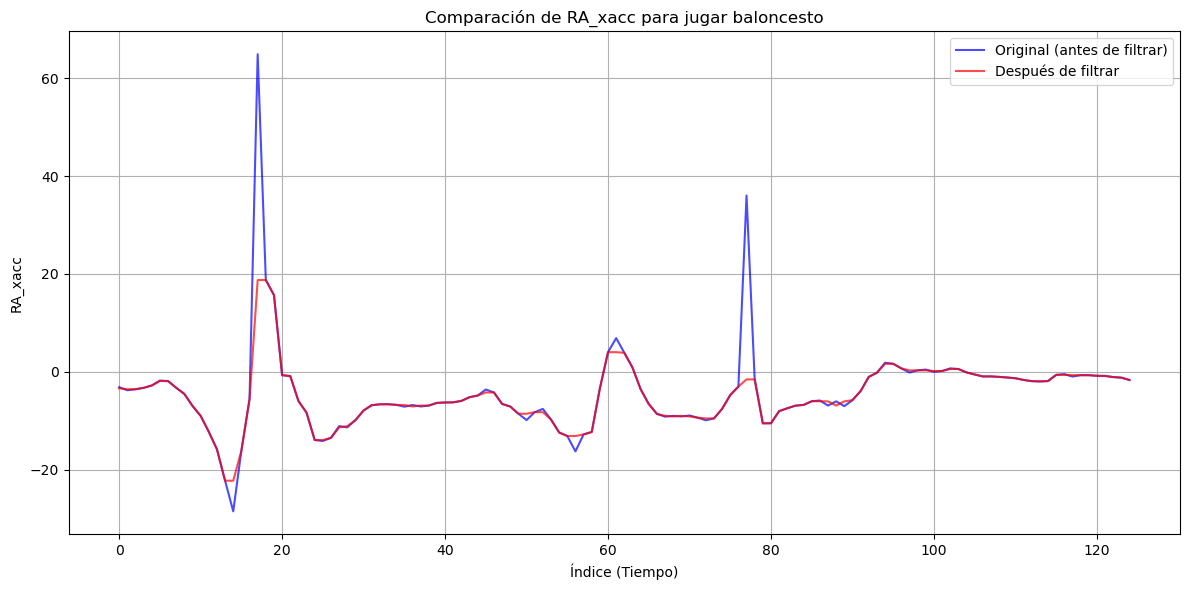

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

# Define la columna que deseas graficar
columna = 'RA_xacc'  # Cambia este valor para usar otra columna

# Ejemplo: selecciona solo el segmento y persona especificados
segmento_elegido = 'a19p1s03.txt'
persona_elegida = 'p1'

# Filtrar el DataFrame original (dsa_df) y el filtrado (dsaa_no_outlier)
df_original = dsa_df[(dsa_df['segment'] == segmento_elegido) & (dsa_df['person_id'] == persona_elegida)]
df_filtrado = dsaa_no_outlier[(dsaa_no_outlier['segment'] == segmento_elegido) & (dsaa_no_outlier['person_id'] == persona_elegida)]

# Reiniciar índice para asegurar la consistencia al graficar
df_original = df_original.reset_index(drop=True)
df_filtrado = df_filtrado.reset_index(drop=True)

# Ajustar la longitud de ambos DataFrame al mínimo común
min_len = min(len(df_original), len(df_filtrado))
df_original = df_original.iloc[:min_len]
df_filtrado = df_filtrado.iloc[:min_len]

# Graficar la columna elegida de ambos DataFrame
plt.figure(figsize=(12, 6))
plt.plot(df_original[columna], label='Original (antes de filtrar)', color='blue', alpha=0.7)
plt.plot(df_filtrado[columna], label='Después de filtrar', color='red', alpha=0.7)
plt.title(f'Comparación de {columna} para jugar baloncesto')
plt.xlabel('Índice (Tiempo)')
plt.ylabel(columna)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## 2.3. Segmentación

In [16]:
def segmentar_por_3s(df, window_size=75):
    df_segmentado_list = []
    
    # Agrupamos por actividad y persona
    for (actividad, persona), grupo in df.groupby(['activity_label', 'person_id']):
        # Calculamos cuántas ventanas completas se pueden formar en este grupo
        n_segmentos = len(grupo) // window_size
        
        # Si no hay suficientes filas para una ventana completa, se omite este grupo
        if n_segmentos == 0:
            continue
        
        # Seleccionamos solo las filas que completan ventanas completas
        grupo_completo = grupo.iloc[:n_segmentos * window_size].copy()
        grupo_completo.reset_index(drop=True, inplace=True)
        
        # Creamos un índice de segmento para cada ventana
        grupo_completo['segment_index'] = grupo_completo.index // window_size
        
        # Generamos el identificador único concatenando actividad, persona y el índice del segmento
        grupo_completo['segment_3s'] = grupo_completo.apply(
            lambda row: f"{actividad}{persona}{int(row['segment_index'])}", axis=1
        )
        
        df_segmentado_list.append(grupo_completo)
    
    # Concatenamos todos los grupos procesados en un único DataFrame
    return pd.concat(df_segmentado_list, ignore_index=True)

df_unsegmented = dsaa_no_outlier

dsaa_no_outlier3 = segmentar_por_3s(df_unsegmented)
dsaa_no_outlier3

,activity_label,person_id,segment,T_xacc,T_yacc,T_zacc,T_xgyro,T_ygyro,T_zgyro,T_xmag,...,LL_yacc,LL_zacc,LL_xgyro,LL_ygyro,LL_zgyro,LL_xmag,LL_ymag,LL_zmag,segment_index,segment_3s
0,a01,p1,a01p1s01.txt,8.130,1.020,5.384,-0.009,0.002,0.000,-0.787,...,-9.074,2.622,-0.000,-0.012,0.000,0.739,0.301,-0.058,0,a01p10
1,a01,p1,a01p1s01.txt,8.130,1.020,5.384,-0.009,0.014,0.000,-0.787,...,-9.081,2.622,-0.013,-0.012,-0.004,0.740,0.301,-0.058,0,a01p10
2,a01,p1,a01p1s01.txt,8.160,1.020,5.377,0.007,0.018,0.002,-0.787,...,-9.081,2.622,-0.013,0.006,0.003,0.740,0.302,-0.058,0,a01p10
3,a01,p1,a01p1s01.txt,8.160,1.020,5.362,0.009,0.018,0.000,-0.787,...,-9.081,2.622,-0.006,0.006,0.003,0.740,0.301,-0.058,0,a01p10
4,a01,p1,a01p1s01.txt,8.160,1.020,5.377,0.007,0.030,-0.005,-0.787,...,-9.081,2.607,-0.006,0.010,0.003,0.740,0.301,-0.058,0,a01p10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1139995,a19,p8,a19p8s60.txt,16.008,-2.017,0.487,2.027,1.604,0.584,-0.731,...,2.809,-4.593,-0.231,0.181,-2.082,0.569,0.394,0.518,99,a19p899
1139996,a19,p8,a19p8s60.txt,8.282,-0.699,0.487,2.027,1.604,-0.020,-0.731,...,4.323,-4.111,1.817,0.313,-1.022,0.538,0.437,0.504,99,a19p899
1139997,a19,p8,a19p8s60.txt,2.712,-0.699,0.487,1.996,1.466,-0.073,-0.725,...,1.255,-4.111,1.817,0.349,-0.368,0.518,0.473,0.489,99,a19p899
1139998,a19,p8,a19p8s60.txt,2.031,0.500,-0.113,1.996,1.010,-0.073,-0.719,...,15.054,1.294,-0.150,0.349,-0.368,0.504,0.473,0.489,99,a19p899


In [17]:
dsaa_no_outlier3.columns

Index(['activity_label', 'person_id', 'segment', 'T_xacc', 'T_yacc', 'T_zacc',
       'T_xgyro', 'T_ygyro', 'T_zgyro', 'T_xmag', 'T_ymag', 'T_zmag',
       'RA_xacc', 'RA_yacc', 'RA_zacc', 'RA_xgyro', 'RA_ygyro', 'RA_zgyro',
       'RA_xmag', 'RA_ymag', 'RA_zmag', 'LA_xacc', 'LA_yacc', 'LA_zacc',
       'LA_xgyro', 'LA_ygyro', 'LA_zgyro', 'LA_xmag', 'LA_ymag', 'LA_zmag',
       'RL_xacc', 'RL_yacc', 'RL_zacc', 'RL_xgyro', 'RL_ygyro', 'RL_zgyro',
       'RL_xmag', 'RL_ymag', 'RL_zmag', 'LL_xacc', 'LL_yacc', 'LL_zacc',
       'LL_xgyro', 'LL_ygyro', 'LL_zgyro', 'LL_xmag', 'LL_ymag', 'LL_zmag',
       'segment_index', 'segment_3s'],
      dtype='object')

In [18]:
dsaa_no_outlier3.dtypes

activity_label     object
person_id          object
segment            object
T_xacc            float64
T_yacc            float64
T_zacc            float64
T_xgyro           float64
T_ygyro           float64
T_zgyro           float64
T_xmag            float64
T_ymag            float64
T_zmag            float64
RA_xacc           float64
RA_yacc           float64
RA_zacc           float64
RA_xgyro          float64
RA_ygyro          float64
RA_zgyro          float64
RA_xmag           float64
RA_ymag           float64
RA_zmag           float64
LA_xacc           float64
LA_yacc           float64
LA_zacc           float64
LA_xgyro          float64
LA_ygyro          float64
LA_zgyro          float64
LA_xmag           float64
LA_ymag           float64
LA_zmag           float64
RL_xacc           float64
RL_yacc           float64
RL_zacc           float64
RL_xgyro          float64
RL_ygyro          float64
RL_zgyro          float64
RL_xmag           float64
RL_ymag           float64
RL_zmag     

In [19]:
dsaa_no_outlier3.groupby(['activity_label', 'person_id'])['segment_3s'].nunique()

activity_label  person_id
a01             p1           100
                p2           100
                p3           100
                p4           100
                p5           100
                            ... 
a19             p4           100
                p5           100
                p6           100
                p7           100
                p8           100
Name: segment_3s, Length: 152, dtype: int64

## 2.4. Extracción de características

### 2.4.1. Características artesanales

In [22]:
import numpy as np

class InertialSensor:
    def __init__(self, x, y, z):
        """
        Inicializa el acelerómetro con sus 3 señales.
        
        Parámetros:
          x: array-like, señal del eje x.
          y: array-like, señal del eje y.
          z: array-like, señal del eje z.
        """
        self.x = np.array(x)
        self.y = np.array(y)
        self.z = np.array(z)
        
    def compute_magnitude(self):
        return np.sqrt(self.x**2 + self.y**2 + self.z**2)
    
    def extract_features(self):
        # 1. Medias de cada eje
        mean_x = np.mean(self.x)
        mean_y = np.mean(self.y)
        mean_z = np.mean(self.z)
        
        # 2. Desviaciones estándar
        std_x = np.std(self.x)
        std_y = np.std(self.y)
        std_z = np.std(self.z)
        
        # 3. Valores máximos
        max_x = np.max(self.x)
        max_y = np.max(self.y)
        max_z = np.max(self.z)
        
        # 4. Correlaciones entre cada par de ejes
        corr_xy = np.corrcoef(self.x, self.y)[0, 1]
        corr_xz = np.corrcoef(self.x, self.z)[0, 1]
        corr_yz = np.corrcoef(self.y, self.z)[0, 1]
        
        # 5,6,7,8. Features derivadas de la magnitud
        magnitude = self.compute_magnitude()
        mean_magnitude = np.mean(magnitude)
        std_magnitude = np.std(magnitude)
        auc = np.sum(magnitude)
        mean_diff = np.mean(np.diff(magnitude)) if len(magnitude) > 1 else 0.0
        
        # Vector de features
        feature_vector = np.array([
            mean_x, mean_y, mean_z,
            std_x, std_y, std_z,
            max_x, max_y, max_z,
            corr_xy, corr_xz, corr_yz,
            mean_magnitude, std_magnitude, auc, mean_diff
        ])
        
        return feature_vector

In [52]:
import numpy as np
import pandas as pd

# Assume dsaa_no_outlier3 has a column 'person_id'
df_to_extract_features = dsaa_no_outlier3

numeric_features_list = []
labels = []
person_ids = []  # new list to collect person IDs

for seg, group in df_to_extract_features.groupby("segment_3s"):
    # Extract person ID (assuming column named 'person_id')
    pid = group["person_id"].iloc[0]

    # Torso
    T_features = InertialSensor(group.T_xacc, group.T_yacc, group.T_zacc).extract_features()
    T_gyro_features = InertialSensor(group.T_xgyro, group.T_ygyro, group.T_zgyro).extract_features()
    T_mag_features = InertialSensor(group.T_xmag, group.T_ymag, group.T_zmag).extract_features()

    # Right Arm
    RA_features = InertialSensor(group.RA_xacc, group.RA_yacc, group.RA_zacc).extract_features()
    RA_gyro_features = InertialSensor(group.RA_xgyro, group.RA_ygyro, group.RA_zgyro).extract_features()
    RA_mag_features = InertialSensor(group.RA_xmag, group.RA_ymag, group.RA_zmag).extract_features()

    # Left Arm
    LA_features = InertialSensor(group.LA_xacc, group.LA_yacc, group.LA_zacc).extract_features()
    LA_gyro_features = InertialSensor(group.LA_xgyro, group.LA_ygyro, group.LA_zgyro).extract_features()
    LA_mag_features = InertialSensor(group.LA_xmag, group.LA_ymag, group.LA_zmag).extract_features()

    # Right Leg
    RL_features = InertialSensor(group.RL_xacc, group.RL_yacc, group.RL_zacc).extract_features()
    RL_gyro_features = InertialSensor(group.RL_xgyro, group.RL_ygyro, group.RL_zgyro).extract_features()
    RL_mag_features = InertialSensor(group.RL_xmag, group.RL_ymag, group.RL_zmag).extract_features()

    # Left Leg
    LL_features = InertialSensor(group.LL_xacc, group.LL_yacc, group.LL_zacc).extract_features()
    LL_gyro_features = InertialSensor(group.LL_xgyro, group.LL_ygyro, group.LL_zgyro).extract_features()
    LL_mag_features = InertialSensor(group.LL_xmag, group.LL_ymag, group.LL_zmag).extract_features()
    
    # Combine all feature sets into one row and convert numeric values to float
    feature_vector = np.concatenate([
        T_features, T_gyro_features, T_mag_features,
        RA_features, RA_gyro_features, RA_mag_features,
        LA_features, LA_gyro_features, LA_mag_features,
        RL_features, RL_gyro_features, RL_mag_features,
        LL_features, LL_gyro_features, LL_mag_features
    ]).astype(float)
    
    numeric_features_list.append(feature_vector)
    labels.append(group["activity_label"].iloc[0])
    person_ids.append(pid)  # add the person ID to the list

# Generate feature column names
sensor_locations = ["T", "RA", "LA", "RL", "LL"]
sensor_types = ["acc", "gyro", "mag"]
feature_names = [
    "mean_x", "mean_y", "mean_z", "std_x", "std_y", "std_z",
    "max_x", "max_y", "max_z", "corr_xy", "corr_xz", "corr_yz",
    "mean_mag", "std_mag", "auc", "mean_diff"
]

feature_columns = [
    f"{loc}_{typ}_{feat}"
    for loc in sensor_locations
    for typ in sensor_types
    for feat in feature_names
]

# Create DataFrame for numeric features and convert to float
df_numeric = pd.DataFrame(np.array(numeric_features_list), columns=feature_columns)

# Create DataFrame for labels
df_labels = pd.DataFrame(labels, columns=["activity"])

# Create DataFrame for person IDs
df_person_id = pd.DataFrame(person_ids, columns=["person_id"])

# Concatenate numeric features, labels, and person IDs
examples_fe_artesanal = pd.concat([df_numeric, df_labels, df_person_id], axis=1)

# Optionally, check the first few rows and data types
display(examples_fe_artesanal.head())
display(examples_fe_artesanal.dtypes)

,T_acc_mean_x,T_acc_mean_y,T_acc_mean_z,T_acc_std_x,T_acc_std_y,T_acc_std_z,T_acc_max_x,T_acc_max_y,T_acc_max_z,T_acc_corr_xy,...,LL_mag_max_z,LL_mag_corr_xy,LL_mag_corr_xz,LL_mag_corr_yz,LL_mag_mean_mag,LL_mag_std_mag,LL_mag_auc,LL_mag_mean_diff,activity,person_id
0,8.014,1.057,5.561,0.128,0.037,0.186,8.160,1.175,6.106,-0.902,...,-0.056,-0.146,0.067,0.121,0.800,0.000,60.035,0.000,a01,p1
1,7.918,1.128,5.683,0.056,0.021,0.095,8.011,1.183,5.875,0.347,...,-0.056,-0.168,0.241,-0.094,0.801,0.000,60.074,-0.000,a01,p1
2,7.907,1.164,5.700,0.024,0.013,0.033,7.966,1.183,5.768,-0.272,...,-0.055,0.036,0.051,-0.062,0.803,0.000,60.206,0.000,a01,p1
3,7.927,1.161,5.658,0.042,0.017,0.073,8.026,1.198,5.798,-0.685,...,-0.055,0.188,0.184,-0.338,0.803,0.000,60.190,-0.000,a01,p1
4,7.943,1.168,5.639,0.052,0.016,0.085,8.048,1.197,5.768,-0.506,...,-0.055,-0.189,0.335,-0.053,0.802,0.000,60.172,0.000,a01,p1


T_acc_mean_x        float64
T_acc_mean_y        float64
T_acc_mean_z        float64
T_acc_std_x         float64
T_acc_std_y         float64
                     ...   
LL_mag_std_mag      float64
LL_mag_auc          float64
LL_mag_mean_diff    float64
activity             object
person_id            object
Length: 242, dtype: object

In [208]:
examples_fe_artesanal

,T_acc_mean_x,T_acc_mean_y,T_acc_mean_z,T_acc_std_x,T_acc_std_y,T_acc_std_z,T_acc_max_x,T_acc_max_y,T_acc_max_z,T_acc_corr_xy,...,LL_mag_max_z,LL_mag_corr_xy,LL_mag_corr_xz,LL_mag_corr_yz,LL_mag_mean_mag,LL_mag_std_mag,LL_mag_auc,LL_mag_mean_diff,activity,person_id
0,8.014,1.057,5.561,0.128,0.037,0.186,8.160,1.175,6.106,-0.902,...,-0.056,-0.146,0.067,0.121,0.800,0.000,60.035,0.000,a01,p1
1,7.918,1.128,5.683,0.056,0.021,0.095,8.011,1.183,5.875,0.347,...,-0.056,-0.168,0.241,-0.094,0.801,0.000,60.074,-0.000,a01,p1
2,7.907,1.164,5.700,0.024,0.013,0.033,7.966,1.183,5.768,-0.272,...,-0.055,0.036,0.051,-0.062,0.803,0.000,60.206,0.000,a01,p1
3,7.927,1.161,5.658,0.042,0.017,0.073,8.026,1.198,5.798,-0.685,...,-0.055,0.188,0.184,-0.338,0.803,0.000,60.190,-0.000,a01,p1
4,7.943,1.168,5.639,0.052,0.016,0.085,8.048,1.197,5.768,-0.506,...,-0.055,-0.189,0.335,-0.053,0.802,0.000,60.172,0.000,a01,p1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15195,9.416,-0.805,0.122,6.827,2.198,1.321,23.786,3.375,3.314,-0.448,...,-0.027,0.511,-0.086,-0.450,0.861,0.047,64.589,0.001,a19,p8
15196,9.582,-0.937,0.895,4.933,1.765,1.476,18.389,2.197,4.671,-0.330,...,0.667,-0.264,-0.735,-0.106,0.930,0.016,69.735,0.000,a19,p8
15197,9.019,-0.491,1.279,6.547,1.853,3.090,27.041,1.795,12.021,-0.604,...,0.675,-0.362,-0.941,0.523,0.932,0.013,69.889,0.000,a19,p8
15198,9.684,-0.086,1.712,3.877,1.807,2.332,23.067,2.468,9.394,-0.571,...,0.626,-0.206,-0.812,-0.356,0.912,0.008,68.395,-0.000,a19,p8


### 2.4.2. Características automáticas

In [166]:
meta_cols = ["activity_label","person_id","segment","segment_index","segment_3s"]
sensor_cols = [c for c in dsaa_no_outlier3.columns if c not in meta_cols]  

Tenemos:
- **1140000**: total de mediciones
- **45**: total de señales de sensores. 5 partes del cuerpo por 3 sensores con 3 ejes cada uno = 5x3x3 = 45

In [168]:
import numpy as np

data = dsaa_no_outlier3[sensor_cols].values  
data.shape

(1140000, 45)

In [170]:
groups = dsaa_no_outlier3.groupby("segment_3s")[sensor_cols]
segments = np.stack([grp.values for _, grp in groups], axis=0)

Tenemos:
- **15200**: Cantidad total de segmentos de 3s. 15200 porque 1140000 mediciones en todo el dataset los cuales segmentamos en 3s y como cada segundo es 25Hz terminamos con: total de mediciones / mediciones en un segmento = total de mediciones / (segundos * hz por segundo) = 1140000 / (3 * 25Hz) = 15200
- **75**: es el tamaño de 1 segmento. 75 porque 25Hz por 3s = 25*3 = 75 mediciones por segmento de 3s 
- **45**: La cantidad de sensores. 45 porque 5 partes del cuerpo x 3 sensores x 3 axis de cada sensor =  5*3*3 = 45

In [172]:
segments.shape

# segments.shape == (N, 75, C)
# N = nº de ventanas, 
# 75 = mediciones por ventana de 3s
# C = len(sensor_cols), cantidad de señales de sensores

(15200, 75, 45)

Model: "resnext_classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 75, 45)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 75, 45)    │        180 │ input_layer[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 75, 64)    │     14,400 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 75, 64)    │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 75, 64)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 75, 64)    │          0 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 37, 64)    │          0 │ dropout[0][0]     │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 37, 64)    │      4,096 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 37, 64)    │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 37, 64)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 37, 16)    │          0 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 37, 16)    │          0 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 37, 16)    │          0 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_3 (Lambda)   │ (None, 37, 16)    │          0 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 37, 16)    │        768 │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 37, 16)    │        768 │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 37, 16)    │        768 │ lambda_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 37, 16)    │        768 │ lambda_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 37, 64)    │          0 │ conv1d_2[0][0],   │
│ (Concatenate)       │                   │            │ conv1d_3[0][0],   │
│                     │                   │            │ conv1d_4[0][0],   │
│                     │                   │            │ conv1d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 37, 64)    │        256 │ concatenate[0][0

 Total params: 242,439 (947.03 KB)

 Trainable params: 238,381 (931.18 KB)

 Non-trainable params: 4,058 (15.85 KB)

None
Epoch 1/50
296/296 ━━━━━━━━━━━━━━━━━━━━ 30s 44ms/step - accuracy: 0.5422 - loss: 1.6281 - val_accuracy: 0.5884 - val_loss: 1.5343 - learning_rate: 5.0000e-04
Epoch 2/50
296/296 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - accuracy: 0.9394 - loss: 0.1795 - val_accuracy: 0.7200 - val_loss: 1.5106 - learning_rate: 5.0000e-04
Epoch 3/50
296/296 ━━━━━━━━━━━━━━━━━━━━ 12s 40ms/step - accuracy: 0.9681 - loss: 0.1086 - val_accuracy: 0.7395 - val_loss: 1.4224 - learning_rate: 5.0000e-04
Epoch 4/50
296/296 ━━━━━━━━━━━━━━━━━━━━ 12s 42ms/step - accuracy: 0.9770 - loss: 0.0747 - val_accuracy: 0.6784 - val_loss: 1.4824 - learning_rate: 5.0000e-04
Epoch 5/50
296/296 ━━━━━━━━━━━━━━━━━━━━ 12s 40ms/step - accuracy: 0.9731 - loss: 0.0862 - val_accuracy: 0.6805 - val_loss: 1.7247 - learning_rate: 5.0000e-04
Epoch 6/50
296/296 ━━━━━━━━━━━━━━━━━━━━ 12s 40ms/step - accuracy: 0.9782 - loss: 0.0724 - val_accuracy: 0.7389 - val_loss: 1.3944 - learning_rate: 5.0000e-04
Epoch 7/50
296/296 ━━━━━━━━━━━━━━━━━━━━ 12s 42m

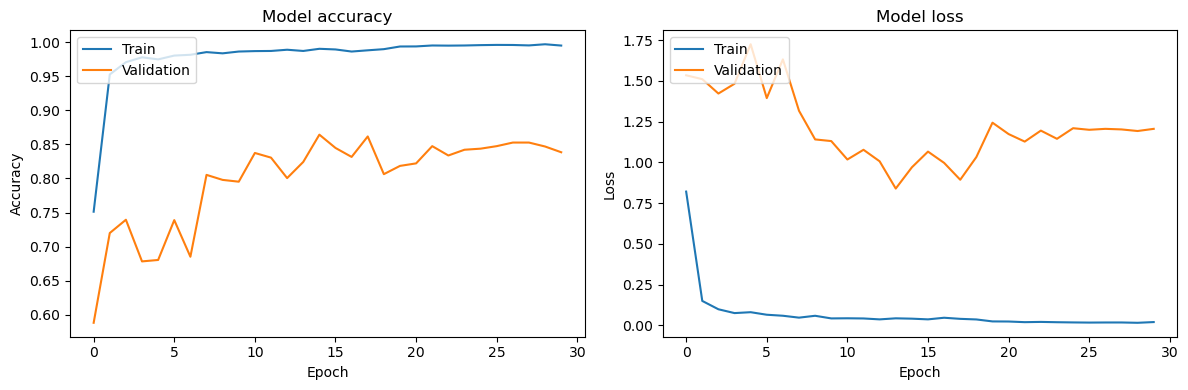

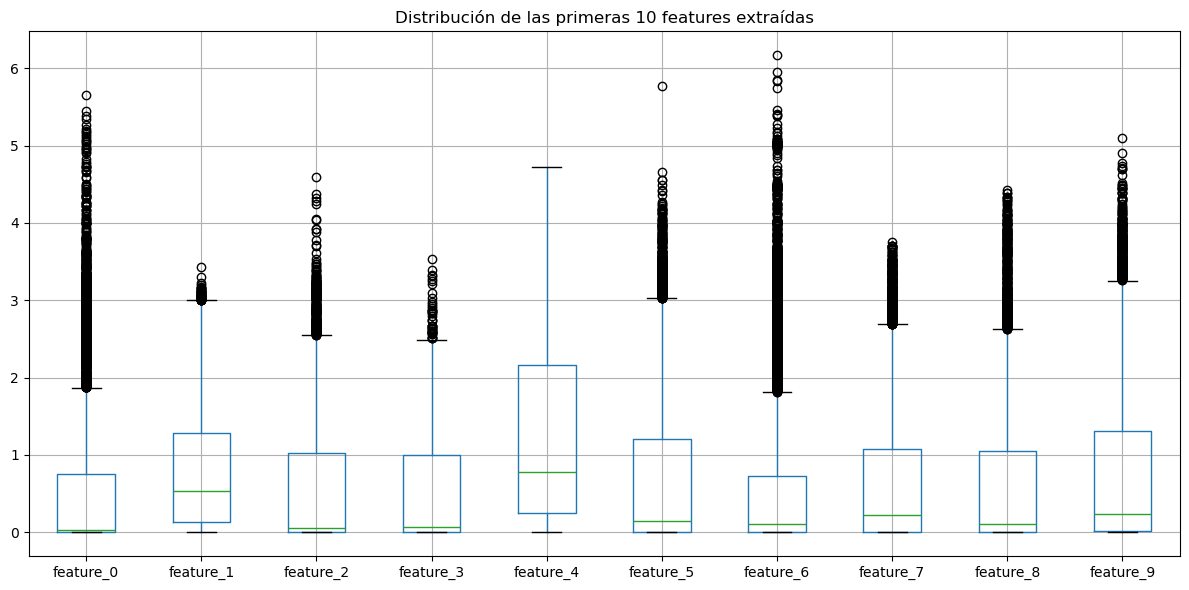

In [174]:
import numpy as np                                         # manejo de arrays
import pandas as pd                                        # DataFrame
from tensorflow.keras import layers, Model, Input          # Functional API
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
import tensorflow as tf

# — 0) FUNCIONES PARA CREAR BLOQUES RESNEXT —
def resnext_block(x, filters, cardinality=8, strides=1, dropout_rate=0.2):
    """
    Implementa un bloque ResNeXt con cardinalidad y regularización
    Args:
        x: Input tensor
        filters: Número de filtros en la capa final del bloque
        cardinality: Número de grupos para la transformación (cardinalidad)
        strides: Stride para la primera capa de cada bloque
        dropout_rate: Tasa de dropout para regularización
    """
    # Guarda el input para la conexión residual
    shortcut = x
    
    # Split-Transform-Merge con cardinalidad
    # Primero reducimos la dimensionalidad
    reduced_filters = filters // 2
    
    x = layers.Conv1D(reduced_filters, kernel_size=1, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    
    # Transformación con cardinalidad
    # Usamos grupos de convolución para implementar cardinalidad
    groups = []
    group_width = max(1, reduced_filters // cardinality)  # Aseguramos al menos 1 filtro por grupo
    
    for i in range(cardinality):
        group = layers.Lambda(lambda z: z[:, :, i * group_width:(i + 1) * group_width 
                              if (i+1)*group_width <= reduced_filters else reduced_filters])(x)
        group = layers.Conv1D(group_width, kernel_size=3, strides=strides, 
                             padding='same', use_bias=False)(group)
        groups.append(group)
    
    # Concatenamos todos los grupos
    x = layers.Concatenate(axis=-1)(groups)
    
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    
    # Dropout para regularización
    x = layers.Dropout(dropout_rate)(x)
    
    # Expandimos de vuelta la dimensionalidad
    x = layers.Conv1D(filters, kernel_size=1, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    
    # Si cambiamos la dimensionalidad temporal o de canales, necesitamos
    # adaptar la conexión residual con una proyección 1x1
    if strides != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv1D(filters, kernel_size=1, strides=strides, padding='same', use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
    
    # Suma con la conexión residual
    x = layers.add([x, shortcut])
    x = layers.Activation('relu')(x)
    
    return x

# — 1) PREPARAR VENTANAS (N,75,C) Y ETIQUETAS —  
df = dsaa_no_outlier3                                     # tu DataFrame con segment_3s  
meta_cols = ["activity_label","person_id","segment","segment_index","segment_3s"]  
sensor_cols = [c for c in df.columns if c not in meta_cols]  # 45 columnas de sensor  
groups   = df.groupby("segment_3s")[sensor_cols]           # N grupos de 75 filas  
segments = np.stack([grp.values for _, grp in groups], axis=0)  # (N,75,45)  
labels     = df.groupby("segment_3s")["activity_label"].first().values  
person_ids = df.groupby("segment_3s")["person_id"].first().values  
N, T, C = segments.shape  # N ventanas, T=75, C=45  

# — 2) DEFINIR MODELO RESNEXT PARA EXTRACCIÓN DE FEATURES —  
inputs = Input(shape=(T, C))                    # capa Input (75, 45)

# Normalización de datos iniciales
x = layers.BatchNormalization()(inputs)

# Primera capa de convolución con regularización
x = layers.Conv1D(64, kernel_size=5, strides=1, padding='same', 
                 use_bias=False, kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Dropout(0.2)(x)
x = layers.MaxPooling1D(pool_size=2)(x)         # → (37, 64)

# Bloques ResNeXt con menor cardinalidad y regularización
# Reducimos la cardinalidad para evitar sobreajuste
# Primer grupo de bloques (64 filtros)
x = resnext_block(x, filters=128, cardinality=4, strides=1, dropout_rate=0.2)
x = resnext_block(x, filters=128, cardinality=4, strides=1, dropout_rate=0.2)
x = layers.MaxPooling1D(pool_size=2)(x)         # → (18, 128)

# Segundo grupo de bloques (128 filtros)
x = resnext_block(x, filters=256, cardinality=4, strides=1, dropout_rate=0.3)
x = resnext_block(x, filters=256, cardinality=4, strides=1, dropout_rate=0.3)

# Capa de pooling global para extracción de características
features = layers.GlobalAveragePooling1D()(x)    # → (256,)
features = layers.Dropout(0.5)(features)  # Fuerte regularización antes de la clasificación

# — 2.1) CREAR DOS MODELOS: UNO PARA ENTRENAR Y OTRO PARA EXTRAER CARACTERÍSTICAS —
# Modelo para entrenar (con capa de clasificación)
# Añadimos una capa de clasificación para entrenar el modelo
num_classes = len(np.unique(labels))
classification_output = layers.Dense(num_classes, activation='softmax', name='classification')(features)

# Modelo completo para entrenar
full_model = Model(inputs=inputs, outputs=classification_output, name='resnext_classifier')

# Modelo para extraer características (sin la capa de clasificación)
feature_extractor = Model(inputs=inputs, outputs=features, name='resnext_feature_extractor')

# Opcional: Mostrar resumen del modelo
print(full_model.summary())

# — 3) PREPARAR DATOS PARA ENTRENAMIENTO (TRAIN/VAL/TEST) —
# Convertir etiquetas a formato one-hot para entrenar
# Mapear las etiquetas a índices enteros
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(labels)
one_hot_labels = to_categorical(encoded_labels)

# Dividir datos para entrenamiento, validación y prueba
# Usamos person_id para asegurar que una persona no aparezca en diferentes conjuntos
unique_persons = np.unique(person_ids)
train_persons, temp_persons = train_test_split(unique_persons, test_size=0.3, random_state=42)
val_persons, test_persons = train_test_split(temp_persons, test_size=0.5, random_state=42)

# Crear máscaras para train, val y test
train_mask = np.isin(person_ids, train_persons)
val_mask = np.isin(person_ids, val_persons)
test_mask = np.isin(person_ids, test_persons)

X_train, y_train = segments[train_mask], one_hot_labels[train_mask]
X_val, y_val = segments[val_mask], one_hot_labels[val_mask]
X_test, y_test = segments[test_mask], one_hot_labels[test_mask]

# — 4) ENTRENAR EL MODELO —
# Compilar modelo con regularización en la pérdida
full_model.compile(
    optimizer=Adam(learning_rate=0.0005),  # Menor tasa de aprendizaje
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks para mejorar el entrenamiento
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6),
    # Opcional: Añadir TensorBoard para visualizar mejor el entrenamiento
    # tf.keras.callbacks.TensorBoard(log_dir='./logs', histogram_freq=1)
]

# Data augmentation para reducir sobreajuste
def data_augmentation(x_batch, y_batch):
    # Añadir ruido aleatorio
    noise_factor = 0.05
    x_batch_noisy = x_batch + np.random.normal(0, noise_factor, x_batch.shape)
    # Time warping (estiramiento/compresión temporal simple)
    warped_batch = []
    for sample in x_batch_noisy:
        if np.random.random() > 0.5:
            # Simular time warping con interpolación
            indices = np.linspace(0, len(sample)-1, len(sample))
            warped_indices = indices + np.sin(np.linspace(0, np.pi, len(sample))) * 3
            warped_indices = np.clip(warped_indices, 0, len(sample)-1)
            warped_sample = np.array([np.interp(warped_indices, indices, sample[:,c]) for c in range(sample.shape[1])]).T
            warped_batch.append(warped_sample)
        else:
            warped_batch.append(sample)
    return np.array(warped_batch), y_batch

# Generador de datos con augmentation
def train_generator(x_data, y_data, batch_size=32):
    n_samples = len(x_data)
    while True:
        indices = np.random.permutation(n_samples)
        for i in range(0, n_samples, batch_size):
            batch_indices = indices[i:min(i+batch_size, n_samples)]
            x_batch, y_batch = x_data[batch_indices], y_data[batch_indices]
            # Aplicar data augmentation
            yield data_augmentation(x_batch, y_batch)

# Entrenar el modelo con data augmentation
epochs = 50
batch_size = 32  # Batch size más pequeño

history = full_model.fit(
    train_generator(X_train, y_train, batch_size),
    steps_per_epoch=len(X_train) // batch_size,
    validation_data=(X_val, y_val),
    epochs=epochs,
    callbacks=callbacks,
    verbose=1
)

# Evaluar el modelo en el conjunto de prueba
test_loss, test_acc = full_model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

# — 5) USAR EL MODELO ENTRENADO PARA EXTRAER CARACTERÍSTICAS —
# Ahora usamos el extractor de características entrenado
deep_features = feature_extractor.predict(segments, batch_size=64)  # (N, 256)

# — 6) MONTAR DataFrame FINAL —  
feat_cols = [f"feature_{i}" for i in range(deep_features.shape[1])]  # 256 nombres  
df_feats = pd.DataFrame(deep_features, columns=feat_cols)           # (N, 256)
df_feats["label"] = labels                                         # añade label
df_feats["person_id"] = person_ids                                 # añade person_id
examples_fe_resnext = df_feats

# Guardar el modelo entrenado
feature_extractor.save('resnext_feature_extractor.h5')

# Opcional: Visualizar la curva de aprendizaje
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.tight_layout()
plt.show()

# Opcional: Visualizar distribución de features
plt.figure(figsize=(12, 6))
df_feats.iloc[:, :10].boxplot()
plt.title('Distribución de las primeras 10 features extraídas')
plt.tight_layout()
plt.show()

In [206]:
examples_fe_resnext

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_248,feature_249,feature_250,feature_251,feature_252,feature_253,feature_254,feature_255,label,person_id
0,0.000,0.144,0.000,0.000,1.163,0.000,0.000,0.003,0.000,0.012,...,0.034,0.553,0.000,0.146,0.011,0.022,0.000,0.000,a01,p1
1,0.000,0.161,0.000,0.000,1.173,0.000,0.000,0.003,0.000,0.012,...,0.130,0.593,0.000,0.083,0.011,0.020,0.000,0.000,a01,p1
2,0.000,0.164,0.000,0.000,1.193,0.000,0.000,0.003,0.000,0.011,...,0.133,0.654,0.000,0.016,0.009,0.018,0.000,0.000,a01,p1
3,0.000,0.174,0.000,0.000,1.185,0.000,0.000,0.002,0.000,0.011,...,0.110,0.635,0.000,0.032,0.010,0.018,0.000,0.000,a01,p1
4,0.000,0.167,0.000,0.000,1.189,0.000,0.000,0.002,0.000,0.012,...,0.110,0.618,0.000,0.046,0.010,0.017,0.000,0.000,a01,p1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15195,2.912,0.814,1.025,1.000,0.379,2.496,3.337,0.531,0.439,2.052,...,1.611,0.876,3.381,1.455,0.665,0.379,0.425,0.176,a19,p8
15196,1.356,0.445,1.131,0.806,0.977,2.278,1.882,1.454,0.767,1.973,...,1.363,0.452,2.486,0.467,0.696,0.245,0.465,0.108,a19,p8
15197,3.296,1.535,3.378,1.988,0.328,3.550,4.369,1.464,0.538,2.925,...,1.838,2.543,4.318,1.801,0.430,0.172,0.922,0.005,a19,p8
15198,0.605,0.693,1.406,0.660,1.165,1.264,1.230,1.093,0.000,1.981,...,1.354,0.807,1.300,0.773,0.258,0.057,0.125,0.000,a19,p8


### 2.4.3. Fusión de características

In [210]:
examples_fe_artesanal

,T_acc_mean_x,T_acc_mean_y,T_acc_mean_z,T_acc_std_x,T_acc_std_y,T_acc_std_z,T_acc_max_x,T_acc_max_y,T_acc_max_z,T_acc_corr_xy,...,LL_mag_max_z,LL_mag_corr_xy,LL_mag_corr_xz,LL_mag_corr_yz,LL_mag_mean_mag,LL_mag_std_mag,LL_mag_auc,LL_mag_mean_diff,activity,person_id
0,8.014,1.057,5.561,0.128,0.037,0.186,8.160,1.175,6.106,-0.902,...,-0.056,-0.146,0.067,0.121,0.800,0.000,60.035,0.000,a01,p1
1,7.918,1.128,5.683,0.056,0.021,0.095,8.011,1.183,5.875,0.347,...,-0.056,-0.168,0.241,-0.094,0.801,0.000,60.074,-0.000,a01,p1
2,7.907,1.164,5.700,0.024,0.013,0.033,7.966,1.183,5.768,-0.272,...,-0.055,0.036,0.051,-0.062,0.803,0.000,60.206,0.000,a01,p1
3,7.927,1.161,5.658,0.042,0.017,0.073,8.026,1.198,5.798,-0.685,...,-0.055,0.188,0.184,-0.338,0.803,0.000,60.190,-0.000,a01,p1
4,7.943,1.168,5.639,0.052,0.016,0.085,8.048,1.197,5.768,-0.506,...,-0.055,-0.189,0.335,-0.053,0.802,0.000,60.172,0.000,a01,p1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15195,9.416,-0.805,0.122,6.827,2.198,1.321,23.786,3.375,3.314,-0.448,...,-0.027,0.511,-0.086,-0.450,0.861,0.047,64.589,0.001,a19,p8
15196,9.582,-0.937,0.895,4.933,1.765,1.476,18.389,2.197,4.671,-0.330,...,0.667,-0.264,-0.735,-0.106,0.930,0.016,69.735,0.000,a19,p8
15197,9.019,-0.491,1.279,6.547,1.853,3.090,27.041,1.795,12.021,-0.604,...,0.675,-0.362,-0.941,0.523,0.932,0.013,69.889,0.000,a19,p8
15198,9.684,-0.086,1.712,3.877,1.807,2.332,23.067,2.468,9.394,-0.571,...,0.626,-0.206,-0.812,-0.356,0.912,0.008,68.395,-0.000,a19,p8


In [212]:
examples_fe_resnext

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_248,feature_249,feature_250,feature_251,feature_252,feature_253,feature_254,feature_255,label,person_id
0,0.000,0.144,0.000,0.000,1.163,0.000,0.000,0.003,0.000,0.012,...,0.034,0.553,0.000,0.146,0.011,0.022,0.000,0.000,a01,p1
1,0.000,0.161,0.000,0.000,1.173,0.000,0.000,0.003,0.000,0.012,...,0.130,0.593,0.000,0.083,0.011,0.020,0.000,0.000,a01,p1
2,0.000,0.164,0.000,0.000,1.193,0.000,0.000,0.003,0.000,0.011,...,0.133,0.654,0.000,0.016,0.009,0.018,0.000,0.000,a01,p1
3,0.000,0.174,0.000,0.000,1.185,0.000,0.000,0.002,0.000,0.011,...,0.110,0.635,0.000,0.032,0.010,0.018,0.000,0.000,a01,p1
4,0.000,0.167,0.000,0.000,1.189,0.000,0.000,0.002,0.000,0.012,...,0.110,0.618,0.000,0.046,0.010,0.017,0.000,0.000,a01,p1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15195,2.912,0.814,1.025,1.000,0.379,2.496,3.337,0.531,0.439,2.052,...,1.611,0.876,3.381,1.455,0.665,0.379,0.425,0.176,a19,p8
15196,1.356,0.445,1.131,0.806,0.977,2.278,1.882,1.454,0.767,1.973,...,1.363,0.452,2.486,0.467,0.696,0.245,0.465,0.108,a19,p8
15197,3.296,1.535,3.378,1.988,0.328,3.550,4.369,1.464,0.538,2.925,...,1.838,2.543,4.318,1.801,0.430,0.172,0.922,0.005,a19,p8
15198,0.605,0.693,1.406,0.660,1.165,1.264,1.230,1.093,0.000,1.981,...,1.354,0.807,1.300,0.773,0.258,0.057,0.125,0.000,a19,p8


In [222]:
import pandas as pd

# Cargar los DataFrames
df_manuales = examples_fe_artesanal
df_resnext = examples_fe_resnext

# Eliminar columnas redundantes
df_manuales_clean = df_manuales.drop(columns=['activity', 'person_id'])
df_resnext_clean = df_resnext.drop(columns=['label', 'person_id'])

# Renombrar columnas de características para evitar conflictos
df_manuales_clean.columns = [f"artesanal_{col}" for col in df_manuales_clean.columns]
df_resnext_clean.columns = [f"resnext_{col}" for col in df_resnext_clean.columns]

# Concatenar los DataFrames
df_fusionado = pd.concat([df_manuales_clean, df_resnext_clean], axis=1)

# Añadir de nuevo las columnas de metadatos
df_fusionado['activity'] = df_manuales['activity']
df_fusionado['person_id'] = df_manuales['person_id']
df_fusionado

,artesanal_T_acc_mean_x,artesanal_T_acc_mean_y,artesanal_T_acc_mean_z,artesanal_T_acc_std_x,artesanal_T_acc_std_y,artesanal_T_acc_std_z,artesanal_T_acc_max_x,artesanal_T_acc_max_y,artesanal_T_acc_max_z,artesanal_T_acc_corr_xy,...,resnext_feature_248,resnext_feature_249,resnext_feature_250,resnext_feature_251,resnext_feature_252,resnext_feature_253,resnext_feature_254,resnext_feature_255,activity,person_id
0,8.014,1.057,5.561,0.128,0.037,0.186,8.160,1.175,6.106,-0.902,...,0.034,0.553,0.000,0.146,0.011,0.022,0.000,0.000,a01,p1
1,7.918,1.128,5.683,0.056,0.021,0.095,8.011,1.183,5.875,0.347,...,0.130,0.593,0.000,0.083,0.011,0.020,0.000,0.000,a01,p1
2,7.907,1.164,5.700,0.024,0.013,0.033,7.966,1.183,5.768,-0.272,...,0.133,0.654,0.000,0.016,0.009,0.018,0.000,0.000,a01,p1
3,7.927,1.161,5.658,0.042,0.017,0.073,8.026,1.198,5.798,-0.685,...,0.110,0.635,0.000,0.032,0.010,0.018,0.000,0.000,a01,p1
4,7.943,1.168,5.639,0.052,0.016,0.085,8.048,1.197,5.768,-0.506,...,0.110,0.618,0.000,0.046,0.010,0.017,0.000,0.000,a01,p1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15195,9.416,-0.805,0.122,6.827,2.198,1.321,23.786,3.375,3.314,-0.448,...,1.611,0.876,3.381,1.455,0.665,0.379,0.425,0.176,a19,p8
15196,9.582,-0.937,0.895,4.933,1.765,1.476,18.389,2.197,4.671,-0.330,...,1.363,0.452,2.486,0.467,0.696,0.245,0.465,0.108,a19,p8
15197,9.019,-0.491,1.279,6.547,1.853,3.090,27.041,1.795,12.021,-0.604,...,1.838,2.543,4.318,1.801,0.430,0.172,0.922,0.005,a19,p8
15198,9.684,-0.086,1.712,3.877,1.807,2.332,23.067,2.468,9.394,-0.571,...,1.354,0.807,1.300,0.773,0.258,0.057,0.125,0.000,a19,p8


In [220]:
df_fusionado.activity

0        a01
1        a01
2        a01
3        a01
4        a01
        ... 
15195    a19
15196    a19
15197    a19
15198    a19
15199    a19
Name: activity, Length: 15200, dtype: object

In [224]:
df_fusionado.person_id

0        p1
1        p1
2        p1
3        p1
4        p1
         ..
15195    p8
15196    p8
15197    p8
15198    p8
15199    p8
Name: person_id, Length: 15200, dtype: object

## 2.5. Entrenamiento

### 2.5.1. Manuales

#### 2.5.1.1. Evaluación: Características manuales con Cross 10-K fold Cross-Validation

In [306]:
import numpy as np
from scipy import stats
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate, StratifiedKFold

def pipelinear_crossvalidation(model, X, y):
    """
    Ajusta un pipeline (scaler + model) con CV de 10 folds estratificada y reproducible.
    Muestra estadísticas de F1-macro y tiempos de entrenamiento, formateadas en columna.
    """
    scaler = StandardScaler()
    pipe = make_pipeline(scaler, model)
    
    # Validación cruzada estratificada y reproducible
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    
    cv_results = cross_validate(
        estimator=pipe,
        X=X, y=y,
        cv=cv,
        scoring=["f1_macro", "accuracy", "precision_macro", "recall_macro"],
        return_train_score=False
    )
    
    scores = cv_results["test_f1_macro"]
    times  = cv_results["fit_time"]

    all_scores = []
    for i in range(cv.get_n_splits()):
        fold_scores = {
            "f1_macro": cv_results["test_f1_macro"][i],
            "accuracy": cv_results["test_accuracy"][i],
            "precision_macro": cv_results["test_precision_macro"][i],
            "recall_macro": cv_results["test_recall_macro"][i]
        }
        all_scores.append(fold_scores)

    def stats_arr(arr):
        return {
            "Media:":     np.mean(arr),
            "Mediana:":   np.median(arr),
            "Std:":       np.std(arr),
            "Mínimo:":    np.min(arr),
            "Máximo:":    np.max(arr),
        }
    
    stats_scores = stats_arr(scores)
    stats_times  = stats_arr(times)
    
    print("Scores (F1-macro):")
    for i in range(0, len(scores), 5):
        print("  " + "  ".join(f"{s:.4f}" for s in scores[i:i+5]))
    
    print()
    for label, val in stats_scores.items():
        print(f"{label:<20}{val:.4f}")
    
    print("\nTiempos de entrenamiento (s):")
    for i in range(0, len(times), 5):
        print("  " + "  ".join(f"{t:.4f}" for t in times[i:i+5]))
    
    print()
    for label, val in stats_times.items():
        print(f"{label:<20}{val:.4f}")
    
    return scores, times, all_scores

Ejemplos:

In [308]:
X = examples_fe_artesanal.drop(columns=["activity", "person_id"], errors="ignore")
y = examples_fe_artesanal.activity

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [310]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb_results = pipelinear_crossvalidation(nb, X, y_encoded)

Scores (F1-macro):
  0.9577  0.9680  0.9676  0.9585  0.9507
  0.9598  0.9641  0.9530  0.9593  0.9607

Media:              0.9599
Mediana:            0.9595
Std:                0.0053
Mínimo:             0.9507
Máximo:             0.9680

Tiempos de entrenamiento (s):
  0.1658  0.1380  0.1450  0.1360  0.1250
  0.1310  0.1390  0.1520  0.1430  0.1240

Media:              0.1399
Mediana:            0.1385
Std:                0.0119
Mínimo:             0.1240
Máximo:             0.1658


In [312]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr_results = pipelinear_crossvalidation(lr, X, y_encoded)

Scores (F1-macro):
  0.9940  0.9934  0.9941  0.9941  0.9928
  0.9914  0.9934  0.9921  0.9947  0.9960

Media:              0.9936
Mediana:            0.9937
Std:                0.0012
Mínimo:             0.9914
Máximo:             0.9960

Tiempos de entrenamiento (s):
  2.6717  2.4262  2.0742  2.5572  2.7810
  2.6779  2.7146  3.6379  2.2965  2.4671

Media:              2.6304
Mediana:            2.6144
Std:                0.3929
Mínimo:             2.0742
Máximo:             3.6379


In [313]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf_results = pipelinear_crossvalidation(rf, X, y_encoded)

Scores (F1-macro):
  0.9947  0.9961  0.9961  0.9960  0.9928
  0.9954  0.9980  0.9947  0.9948  0.9974

Media:              0.9956
Mediana:            0.9957
Std:                0.0014
Mínimo:             0.9928
Máximo:             0.9980

Tiempos de entrenamiento (s):
  25.4408  24.0671  26.9122  25.6930  25.7678
  25.0883  25.6980  22.1723  22.3807  24.2608

Media:              24.7481
Mediana:            25.2646
Std:                1.4510
Mínimo:             22.1723
Máximo:             26.9122


In [314]:
from sklearn.linear_model import Perceptron
perceptron = Perceptron()
percep_results = pipelinear_crossvalidation(perceptron, X, y_encoded)

Scores (F1-macro):
  0.9883  0.9934  0.9908  0.9882  0.9934
  0.9882  0.9875  0.9901  0.9915  0.9934

Media:              0.9905
Mediana:            0.9905
Std:                0.0023
Mínimo:             0.9875
Máximo:             0.9934

Tiempos de entrenamiento (s):
  1.3461  1.5451  1.7121  2.1173  1.8707
  1.7331  1.5731  2.9727  1.8999  2.0186

Media:              1.8789
Mediana:            1.8019
Std:                0.4256
Mínimo:             1.3461
Máximo:             2.9727


In [315]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb_results = pipelinear_crossvalidation(xgb, X, y_encoded)

Scores (F1-macro):
  0.9980  0.9980  0.9954  0.9974  0.9967
  0.9967  0.9987  0.9967  0.9980  0.9993

Media:              0.9975
Mediana:            0.9977
Std:                0.0011
Mínimo:             0.9954
Máximo:             0.9993

Tiempos de entrenamiento (s):
  22.3125  19.4765  18.8454  18.0193  17.6909
  17.9870  19.1900  18.3076  18.1426  18.9579

Media:              18.8930
Mediana:            18.5765
Std:                1.2674
Mínimo:             17.6909
Máximo:             22.3125


In [316]:
import pandas as pd
import numpy as np

def compute_metrics(folds, agg_func=np.mean):
    """
    Calcula las métricas agregadas (media por defecto) a partir de:
      - folds: lista de dicts [{'f1_macro':…, 'accuracy':…, …}, …]
    """
    f1_list     = [fold["f1_macro"]        for fold in folds]
    acc_list    = [fold["accuracy"]        for fold in folds]
    prec_list   = [fold["precision_macro"] for fold in folds]
    recall_list = [fold["recall_macro"]    for fold in folds]

    return {
        "f1_macro":        agg_func(f1_list),
        "accuracy":        agg_func(acc_list),
        "precision_macro": agg_func(prec_list),
        "recall_macro":    agg_func(recall_list)
    }

# Índice de la “persona 2” en tu estructura
idx = 2

# Llamadas para cada clasificador, extrayendo sólo el grupo [idx]
nb_mean_metric     = compute_metrics(nb_results[idx])
lr_mean_metrics     = compute_metrics(lr_results[idx])
rf_mean_metrics     = compute_metrics(rf_results[idx])
percep_mean_metrics = compute_metrics(percep_results[idx])
xgb_mean_metrics    = compute_metrics(xgb_results[idx])

# Montar el DataFrame con la salida “incorrecta” (idéntica a lo que veías antes)
all_metrics_grouped = {
    "Naive Bayes":          nb_mean_metric,
    "Logistic Regression":  lr_mean_metrics,
    "Random Forest":        rf_mean_metrics,
    "Perceptron":           percep_mean_metrics,
    "XGBoost":              xgb_mean_metrics
}

df_metrics_cv = pd.DataFrame.from_dict(all_metrics_grouped, orient="index")

# Mostrar con 5 decimales
df_metrics_cv.style.format(precision=5)

,f1_macro,accuracy,precision_macro,recall_macro
Naive Bayes,0.95994,0.96026,0.96185,0.96026
Logistic Regression,0.99361,0.99362,0.99371,0.99362
Random Forest,0.99559,0.99559,0.99564,0.99559
Perceptron,0.99048,0.99046,0.99084,0.99046
XGBoost,0.99750,0.99750,0.99753,0.99750


#### 2.5.1.2. Evaluación: Características manuales con Cross-Validation con Grupos usando 8 grupos. 

Para realizar la validación cruzada dejando fuera a 1 particiipante por ronda. Para esto se define una validación cruzada de 8 grupos, de modo que cada persona esté en el set de prueba en cada ronda siendo 8 rondas en total.

**Pipeline con Leave-one-out Cross Validation**: 

In [109]:
import numpy as np
from scipy import stats
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate, GroupKFold

def pipelinear_crossvalidation_groups(model, X, y, groups, n_splits=5):
    """
    Ajusta un pipeline (scaler + model) usando GroupKFold CV con 'n_splits' pliegues.
    Cada grupo indicado en 'groups' queda enteramente en train o en test.
    Muestra estadísticas de F1-macro y tiempos de entrenamiento.
    
    Parámetros
    ----------
    model      : estimador de sklearn (clasificador)
    X          : array-like de características
    y          : array-like de etiquetas
    groups     : array-like de grupos (por ejemplo, person_id)
    n_splits   : número de pliegues para GroupKFold (por defecto 5)
    
    Devuelve
    --------
    scores     : array de f1_macro por pliegue
    times      : array de tiempos de fit por pliegue
    all_scores : lista de dicts con todas las métricas por pliegue
    """
    scaler = StandardScaler()
    pipe = make_pipeline(scaler, model)
    
    # CV por grupos
    cv = GroupKFold(n_splits=n_splits)
    
    cv_results = cross_validate(
        estimator=pipe,
        X=X, y=y,
        groups=groups,
        cv=cv,
        scoring=["f1_macro", "accuracy", "precision_macro", "recall_macro"],
        return_train_score=False,
        n_jobs=-1
    )
    
    # Extraer arrays
    scores = cv_results["test_f1_macro"]
    times  = cv_results["fit_time"]

    # Compilar todas las métricas por pliegue
    all_scores = []
    n_splits_actual = cv.get_n_splits(X, y, groups)
    for i in range(n_splits_actual):
        all_scores.append({
            "f1_macro":        cv_results["test_f1_macro"][i],
            "accuracy":        cv_results["test_accuracy"][i],
            "precision_macro": cv_results["test_precision_macro"][i],
            "recall_macro":    cv_results["test_recall_macro"][i]
        })

    # Función de estadísticas
    def stats_arr(arr):
        return {
            "Media:":   np.mean(arr),
            "Mediana:": np.median(arr),
            "Std:":     np.std(arr),
            "Mínimo:":  np.min(arr),
            "Máximo:":  np.max(arr),
        }

    stats_scores = stats_arr(scores)
    stats_times  = stats_arr(times)

    # Imprimir resultados
    print(f"GroupKFold con {n_splits_actual} pliegues — Scores (F1-macro):")
    for i in range(0, len(scores), 5):
        print("  " + "  ".join(f"{s:.4f}" for s in scores[i:i+5]))
    
    print("\nEstadísticas de F1-macro:")
    for label, val in stats_scores.items():
        print(f"{label:<20}{val:.4f}")
    
    print("\nTiempos de entrenamiento (s):")
    for i in range(0, len(times), 5):
        print("  " + "  ".join(f"{t:.4f}" for t in times[i:i+5]))
    
    print("\nEstadísticas de tiempos de training:")
    for label, val in stats_times.items():
        print(f"{label:<20}{val:.4f}")
    
    return scores, times, all_scores

Dataset con labels e ids:

In [111]:
# Preparamos X, y y groups
X = examples_fe_artesanal.drop(columns=["activity", "person_id"], errors="ignore")
y = examples_fe_artesanal["activity"]
groups = examples_fe_artesanal["person_id"]

# Codificamos las etiquetas
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [119]:
groups

0        p1
1        p1
2        p1
3        p1
4        p1
         ..
15195    p8
15196    p8
15197    p8
15198    p8
15199    p8
Name: person_id, Length: 15200, dtype: object

**Bayes Ingenuo** con Cross-Validation en grupos agrupados por persona:

In [125]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()

nb_results_grouped_by_person = pipelinear_crossvalidation_groups(
    model=nb,
    X=X,
    y=y_encoded,
    groups=groups,
    n_splits=8
) 

GroupKFold con 8 pliegues — Scores (F1-macro):
  0.6452  0.8999  0.9489  0.9055  0.7506
  0.8687  0.9465  0.9442

Estadísticas de F1-macro:
Media:              0.8637
Mediana:            0.9027
Std:                0.1026
Mínimo:             0.6452
Máximo:             0.9489

Tiempos de entrenamiento (s):
  0.5551  0.5210  0.5000  0.4980  0.4830
  0.5480  0.5140  0.5180

Estadísticas de tiempos de training:
Media:              0.5172
Mediana:            0.5160
Std:                0.0230
Mínimo:             0.4830
Máximo:             0.5551


**Regresión Logística** con Cross-Validation en grupos agrupados por persona:

In [127]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)

lr_results_grouped_by_person = pipelinear_crossvalidation_groups(
    model=lr,
    X=X,
    y=y_encoded,
    groups=groups,
    n_splits=8
) 

GroupKFold con 8 pliegues — Scores (F1-macro):
  0.8832  0.9533  0.9113  0.8778  0.9011
  0.9710  0.9517  0.9636

Estadísticas de F1-macro:
Media:              0.9266
Mediana:            0.9315
Std:                0.0351
Mínimo:             0.8778
Máximo:             0.9710

Tiempos de entrenamiento (s):
  8.1538  10.0642  10.6853  8.3064  9.7926
  9.5686  9.2451  10.6732

Estadísticas de tiempos de training:
Media:              9.5611
Mediana:            9.6806
Std:                0.8987
Mínimo:             8.1538
Máximo:             10.6853


**Bósque aleatorio** con Cross-Validation en grupos agrupados por persona:

In [128]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()

rf_results_grouped_by_person = pipelinear_crossvalidation_groups(
    model=rf,
    X=X,
    y=y_encoded,
    groups=groups,
    n_splits=8
) 

GroupKFold con 8 pliegues — Scores (F1-macro):
  0.8992  0.9280  0.9524  0.9750  0.9262
  0.9194  0.9581  0.9054

Estadísticas de F1-macro:
Media:              0.9330
Mediana:            0.9271
Std:                0.0248
Mínimo:             0.8992
Máximo:             0.9750

Tiempos de entrenamiento (s):
  30.0059  27.6602  30.7769  28.4522  28.1932
  31.1300  28.9933  30.3589

Estadísticas de tiempos de training:
Media:              29.4463
Mediana:            29.4996
Std:                1.2096
Mínimo:             27.6602
Máximo:             31.1300


**Perceptron** con Cross-Validation en grupos agrupados por persona:

In [134]:
from sklearn.linear_model import Perceptron
perceptron = Perceptron()

percep_results_grouped_by_person = pipelinear_crossvalidation_groups(
    model=perceptron,
    X=X,
    y=y_encoded,
    groups=groups,
    n_splits=8
) 

GroupKFold con 8 pliegues — Scores (F1-macro):
  0.8371  0.9163  0.8460  0.9205  0.8289
  0.9111  0.9414  0.8148

Estadísticas de F1-macro:
Media:              0.8770
Mediana:            0.8786
Std:                0.0467
Mínimo:             0.8148
Máximo:             0.9414

Tiempos de entrenamiento (s):
  4.5640  4.0569  4.6770  4.6180  4.7200
  5.0251  5.0561  4.1699

Estadísticas de tiempos de training:
Media:              4.6109
Mediana:            4.6475
Std:                0.3335
Mínimo:             4.0569
Máximo:             5.0561


**XGBoost** con Cross-Validation en grupos agrupados por persona:

In [136]:
from xgboost import XGBClassifier
xgb = XGBClassifier()

xgb_results_grouped_by_person = pipelinear_crossvalidation_groups(
    model=xgb,
    X=X,
    y=y_encoded,
    groups=groups,
    n_splits=8
) 

GroupKFold con 8 pliegues — Scores (F1-macro):
  0.8566  0.9313  0.9218  0.9199  0.9305
  0.8928  0.9453  0.8975

Estadísticas de F1-macro:
Media:              0.9120
Mediana:            0.9208
Std:                0.0265
Mínimo:             0.8566
Máximo:             0.9453

Tiempos de entrenamiento (s):
  85.7855  86.2238  87.0888  86.0102  86.6113
  85.7770  87.1168  87.0041

Estadísticas de tiempos de training:
Media:              86.4522
Mediana:            86.4176
Std:                0.5391
Mínimo:             85.7770
Máximo:             87.1168


In [162]:
import pandas as pd
import numpy as np

def compute_metrics(folds, agg_func=np.mean):
    """
    Calcula las métricas agregadas (media por defecto) a partir de:
      - folds: lista de dicts [{'f1_macro':…, 'accuracy':…, …}, …]
    """
    f1_list     = [fold["f1_macro"]        for fold in folds]
    acc_list    = [fold["accuracy"]        for fold in folds]
    prec_list   = [fold["precision_macro"] for fold in folds]
    recall_list = [fold["recall_macro"]    for fold in folds]

    return {
        "f1_macro":        agg_func(f1_list),
        "accuracy":        agg_func(acc_list),
        "precision_macro": agg_func(prec_list),
        "recall_macro":    agg_func(recall_list)
    }

# Índice de la “persona 2” en tu estructura
idx = 2

# Llamadas para cada clasificador, extrayendo sólo el grupo [idx]
nb_mean_metrics_grouped     = compute_metrics(nb_results_grouped_by_person[idx])
lr_mean_metrics_grouped     = compute_metrics(lr_results_grouped_by_person[idx])
rf_mean_metrics_grouped     = compute_metrics(rf_results_grouped_by_person[idx])
percep_mean_metrics_grouped = compute_metrics(percep_results_grouped_by_person[idx])
xgb_mean_metrics_grouped    = compute_metrics(xgb_results_grouped_by_person[idx])

# Montar el DataFrame con la salida “incorrecta” (idéntica a lo que veías antes)
all_metrics_grouped = {
    "Naive Bayes":          nb_mean_metrics_grouped,
    "Logistic Regression":  lr_mean_metrics_grouped,
    "Random Forest":        rf_mean_metrics_grouped,
    "Perceptron":           percep_mean_metrics_grouped,
    "XGBoost":              xgb_mean_metrics_grouped
}

df_metrics_grouped_cv = pd.DataFrame.from_dict(all_metrics_grouped, orient="index")

# Mostrar con 5 decimales
df_metrics_grouped_cv.style.format(precision=5)


,f1_macro,accuracy,precision_macro,recall_macro
Naive Bayes,0.86370,0.87980,0.88335,0.87980
Logistic Regression,0.92663,0.93243,0.94194,0.93243
Random Forest,0.93296,0.94053,0.94935,0.94053
Perceptron,0.87702,0.88664,0.91372,0.88664
XGBoost,0.91197,0.92053,0.93152,0.92053


### 2.5.2. Automáticas

#### 2.5.2.1. Evaluación: Características ResNeXt con Cross 10-K fold Cross-Validation

In [184]:
import numpy as np
from scipy import stats
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate, StratifiedKFold

def pipelinear_crossvalidation(model, X, y):
    """
    Ajusta un pipeline (scaler + model) con CV de 10 folds estratificada y reproducible.
    Muestra estadísticas de F1-macro y tiempos de entrenamiento, formateadas en columna.
    """
    scaler = StandardScaler()
    pipe = make_pipeline(scaler, model)
    
    # Validación cruzada estratificada y reproducible
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    
    cv_results = cross_validate(
        estimator=pipe,
        X=X, y=y,
        cv=cv,
        scoring=["f1_macro", "accuracy", "precision_macro", "recall_macro"],
        return_train_score=False
    )
    
    scores = cv_results["test_f1_macro"]
    times  = cv_results["fit_time"]

    all_scores = []
    for i in range(cv.get_n_splits()):
        fold_scores = {
            "f1_macro": cv_results["test_f1_macro"][i],
            "accuracy": cv_results["test_accuracy"][i],
            "precision_macro": cv_results["test_precision_macro"][i],
            "recall_macro": cv_results["test_recall_macro"][i]
        }
        all_scores.append(fold_scores)

    def stats_arr(arr):
        return {
            "Media:":     np.mean(arr),
            "Mediana:":   np.median(arr),
            "Std:":       np.std(arr),
            "Mínimo:":    np.min(arr),
            "Máximo:":    np.max(arr),
        }
    
    stats_scores = stats_arr(scores)
    stats_times  = stats_arr(times)
    
    print("Scores (F1-macro):")
    for i in range(0, len(scores), 5):
        print("  " + "  ".join(f"{s:.4f}" for s in scores[i:i+5]))
    
    print()
    for label, val in stats_scores.items():
        print(f"{label:<20}{val:.4f}")
    
    print("\nTiempos de entrenamiento (s):")
    for i in range(0, len(times), 5):
        print("  " + "  ".join(f"{t:.4f}" for t in times[i:i+5]))
    
    print()
    for label, val in stats_times.items():
        print(f"{label:<20}{val:.4f}")
    
    return scores, times, all_scores

In [186]:
X = examples_fe_resnext.drop(columns=["label", "person_id"], errors="ignore")
y = examples_fe_resnext.label

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [192]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb_results = pipelinear_crossvalidation(nb, X, y_encoded)

Scores (F1-macro):
  0.9711  0.9785  0.9837  0.9749  0.9798
  0.9755  0.9857  0.9792  0.9799  0.9805

Media:              0.9789
Mediana:            0.9795
Std:                0.0040
Mínimo:             0.9711
Máximo:             0.9857

Tiempos de entrenamiento (s):
  0.1630  0.1110  0.1020  0.1470  0.1170
  0.1260  0.1150  0.1180  0.1500  0.1440

Media:              0.1293
Mediana:            0.1220
Std:                0.0192
Mínimo:             0.1020
Máximo:             0.1630


In [194]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr_results = pipelinear_crossvalidation(lr, X, y_encoded)

Scores (F1-macro):
  0.9967  0.9947  0.9960  0.9941  0.9954
  0.9974  0.9974  0.9947  0.9947  0.9967

Media:              0.9958
Mediana:            0.9957
Std:                0.0012
Mínimo:             0.9941
Máximo:             0.9974

Tiempos de entrenamiento (s):
  2.5422  2.2872  2.3722  2.7381  2.8905
  3.2109  1.8571  2.5300  2.4003  2.6654

Media:              2.5494
Mediana:            2.5361
Std:                0.3471
Mínimo:             1.8571
Máximo:             3.2109


In [195]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf_results = pipelinear_crossvalidation(rf, X, y_encoded)

Scores (F1-macro):
  0.9987  0.9934  0.9960  0.9941  0.9941
  0.9941  0.9980  0.9941  0.9961  0.9967

Media:              0.9955
Mediana:            0.9951
Std:                0.0018
Mínimo:             0.9934
Máximo:             0.9987

Tiempos de entrenamiento (s):
  18.8268  18.4939  19.8319  18.8239  18.8270
  17.6792  19.2838  20.6925  20.1350  20.0445

Media:              19.2638
Mediana:            19.0554
Std:                0.8609
Mínimo:             17.6792
Máximo:             20.6925


In [196]:
from sklearn.linear_model import Perceptron
perceptron = Perceptron()
percep_results = pipelinear_crossvalidation(perceptron, X, y_encoded)

Scores (F1-macro):
  0.9947  0.9922  0.9820  0.9875  0.9908
  0.9947  0.9967  0.9934  0.9928  0.9721

Media:              0.9897
Mediana:            0.9925
Std:                0.0071
Mínimo:             0.9721
Máximo:             0.9967

Tiempos de entrenamiento (s):
  2.6513  1.4221  1.0511  0.9991  1.2251
  1.3261  1.9611  1.4581  1.2381  1.1491

Media:              1.4481
Mediana:            1.2821
Std:                0.4764
Mínimo:             0.9991
Máximo:             2.6513


In [197]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb_results = pipelinear_crossvalidation(xgb, X, y_encoded)

Scores (F1-macro):
  0.9974  0.9947  0.9961  0.9947  0.9941
  0.9934  0.9974  0.9941  0.9967  0.9954

Media:              0.9954
Mediana:            0.9951
Std:                0.0014
Mínimo:             0.9934
Máximo:             0.9974

Tiempos de entrenamiento (s):
  18.2073  24.3063  22.3808  17.9241  16.8723
  16.8901  17.7700  18.4776  16.9835  19.7323

Media:              18.9544
Mediana:            18.0657
Std:                2.3816
Mínimo:             16.8723
Máximo:             24.3063


In [199]:
import pandas as pd
import numpy as np

def compute_metrics(folds, agg_func=np.mean):
    """
    Calcula las métricas agregadas (media por defecto) a partir de:
      - folds: lista de dicts [{'f1_macro':…, 'accuracy':…, …}, …]
    """
    f1_list     = [fold["f1_macro"]        for fold in folds]
    acc_list    = [fold["accuracy"]        for fold in folds]
    prec_list   = [fold["precision_macro"] for fold in folds]
    recall_list = [fold["recall_macro"]    for fold in folds]

    return {
        "f1_macro":        agg_func(f1_list),
        "accuracy":        agg_func(acc_list),
        "precision_macro": agg_func(prec_list),
        "recall_macro":    agg_func(recall_list)
    }

# Índice de la “persona 2” en tu estructura
idx = 2

# Llamadas para cada clasificador, extrayendo sólo el grupo [idx]
nb_mean_metric     = compute_metrics(nb_results[idx])
lr_mean_metrics     = compute_metrics(lr_results[idx])
rf_mean_metrics     = compute_metrics(rf_results[idx])
percep_mean_metrics = compute_metrics(percep_results[idx])
xgb_mean_metrics    = compute_metrics(xgb_results[idx])

# Montar el DataFrame con la salida “incorrecta” (idéntica a lo que veías antes)
all_metrics_grouped = {
    "Naive Bayes":          nb_mean_metric,
    "Logistic Regression":  lr_mean_metrics,
    "Random Forest":        rf_mean_metrics,
    "Perceptron":           percep_mean_metrics,
    "XGBoost":              xgb_mean_metrics
}

df_metrics_cv = pd.DataFrame.from_dict(all_metrics_grouped, orient="index")

# Mostrar con 5 decimales
df_metrics_cv.style.format(precision=5)

,f1_macro,accuracy,precision_macro,recall_macro
Naive Bayes,0.97886,0.97862,0.98176,0.97862
Logistic Regression,0.99578,0.99579,0.99592,0.99579
Random Forest,0.99552,0.99553,0.99562,0.99553
Perceptron,0.98970,0.98987,0.99119,0.98987
XGBoost,0.99539,0.99539,0.99548,0.99539


#### 2.5.2.2. Evaluación: Características ResNeXt con Cross-Validation con Grupos usando 8 grupos. 

In [244]:
import numpy as np
from scipy import stats
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate, GroupKFold

def pipelinear_crossvalidation_groups(model, X, y, groups, n_splits=5):
    """
    Ajusta un pipeline (scaler + model) usando GroupKFold CV con 'n_splits' pliegues.
    Cada grupo indicado en 'groups' queda enteramente en train o en test.
    Muestra estadísticas de F1-macro y tiempos de entrenamiento.
    
    Parámetros
    ----------
    model      : estimador de sklearn (clasificador)
    X          : array-like de características
    y          : array-like de etiquetas
    groups     : array-like de grupos (por ejemplo, person_id)
    n_splits   : número de pliegues para GroupKFold (por defecto 5)
    
    Devuelve
    --------
    scores     : array de f1_macro por pliegue
    times      : array de tiempos de fit por pliegue
    all_scores : lista de dicts con todas las métricas por pliegue
    """
    scaler = StandardScaler()
    pipe = make_pipeline(scaler, model)
    
    # CV por grupos
    cv = GroupKFold(n_splits=n_splits)
    
    cv_results = cross_validate(
        estimator=pipe,
        X=X, y=y,
        groups=groups,
        cv=cv,
        scoring=["f1_macro", "accuracy", "precision_macro", "recall_macro"],
        return_train_score=False,
        n_jobs=-1
    )
    
    # Extraer arrays
    scores = cv_results["test_f1_macro"]
    times  = cv_results["fit_time"]

    # Compilar todas las métricas por pliegue
    all_scores = []
    n_splits_actual = cv.get_n_splits(X, y, groups)
    for i in range(n_splits_actual):
        all_scores.append({
            "f1_macro":        cv_results["test_f1_macro"][i],
            "accuracy":        cv_results["test_accuracy"][i],
            "precision_macro": cv_results["test_precision_macro"][i],
            "recall_macro":    cv_results["test_recall_macro"][i]
        })

    # Función de estadísticas
    def stats_arr(arr):
        return {
            "Media:":   np.mean(arr),
            "Mediana:": np.median(arr),
            "Std:":     np.std(arr),
            "Mínimo:":  np.min(arr),
            "Máximo:":  np.max(arr),
        }

    stats_scores = stats_arr(scores)
    stats_times  = stats_arr(times)

    # Imprimir resultados
    print(f"GroupKFold con {n_splits_actual} pliegues — Scores (F1-macro):")
    for i in range(0, len(scores), 5):
        print("  " + "  ".join(f"{s:.4f}" for s in scores[i:i+5]))
    
    print("\nEstadísticas de F1-macro:")
    for label, val in stats_scores.items():
        print(f"{label:<20}{val:.4f}")
    
    print("\nTiempos de entrenamiento (s):")
    for i in range(0, len(times), 5):
        print("  " + "  ".join(f"{t:.4f}" for t in times[i:i+5]))
    
    print("\nEstadísticas de tiempos de training:")
    for label, val in stats_times.items():
        print(f"{label:<20}{val:.4f}")
    
    return scores, times, all_scores

In [260]:
X = examples_fe_resnext.drop(columns=["label", "person_id"], errors="ignore")
y = examples_fe_resnext.label

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

Bayes Ingenuo:

In [262]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()

nb_results_grouped_by_person = pipelinear_crossvalidation_groups(
    model=nb,
    X=X,
    y=y_encoded,
    groups=groups,
    n_splits=8
) 

GroupKFold con 8 pliegues — Scores (F1-macro):
  0.8452  0.9728  0.7313  0.9161  0.8660
  0.9197  0.6926  0.7236

Estadísticas de F1-macro:
Media:              0.8334
Mediana:            0.8556
Std:                0.0983
Mínimo:             0.6926
Máximo:             0.9728

Tiempos de entrenamiento (s):
  0.3153  0.3190  0.3520  0.3140  0.3430
  0.3210  0.3390  0.3460

Estadísticas de tiempos de training:
Media:              0.3312
Mediana:            0.3300
Std:                0.0144
Mínimo:             0.3140
Máximo:             0.3520


In [263]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)

lr_results_grouped_by_person = pipelinear_crossvalidation_groups(
    model=lr,
    X=X,
    y=y_encoded,
    groups=groups,
    n_splits=8
) 

GroupKFold con 8 pliegues — Scores (F1-macro):
  0.9883  0.9989  0.8457  0.9937  0.9910
  0.9968  0.8702  0.8734

Estadísticas de F1-macro:
Media:              0.9447
Mediana:            0.9896
Std:                0.0638
Mínimo:             0.8457
Máximo:             0.9989

Tiempos de entrenamiento (s):
  9.8075  11.8166  6.1922  11.2736  11.9987
  12.2287  11.1196  10.1875

Estadísticas de tiempos de training:
Media:              10.5781
Mediana:            11.1966
Std:                1.8383
Mínimo:             6.1922
Máximo:             12.2287


In [265]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()

rf_results_grouped_by_person = pipelinear_crossvalidation_groups(
    model=rf,
    X=X,
    y=y_encoded,
    groups=groups,
    n_splits=8
) 

GroupKFold con 8 pliegues — Scores (F1-macro):
  0.9868  0.9995  0.8012  0.9958  0.9821
  0.9974  0.8930  0.8241

Estadísticas de F1-macro:
Media:              0.9350
Mediana:            0.9845
Std:                0.0780
Mínimo:             0.8012
Máximo:             0.9995

Tiempos de entrenamiento (s):
  20.8511  22.4197  21.3852  21.5602  21.1991
  21.8517  21.1601  21.4942

Estadísticas de tiempos de training:
Media:              21.4902
Mediana:            21.4397
Std:                0.4490
Mínimo:             20.8511
Máximo:             22.4197


In [266]:
from sklearn.linear_model import Perceptron
perceptron = Perceptron()

percep_results_grouped_by_person = pipelinear_crossvalidation_groups(
    model=perceptron,
    X=X,
    y=y_encoded,
    groups=groups,
    n_splits=8
) 

GroupKFold con 8 pliegues — Scores (F1-macro):
  0.9888  0.9984  0.8392  0.9497  0.9979
  0.9963  0.9199  0.8720

Estadísticas de F1-macro:
Media:              0.9453
Mediana:            0.9693
Std:                0.0585
Mínimo:             0.8392
Máximo:             0.9984

Tiempos de entrenamiento (s):
  2.8352  2.8282  2.5062  2.7262  2.6742
  2.6372  2.5382  2.5252

Estadísticas de tiempos de training:
Media:              2.6588
Mediana:            2.6557
Std:                0.1229
Mínimo:             2.5062
Máximo:             2.8352


In [267]:
from xgboost import XGBClassifier
xgb = XGBClassifier()

xgb_results_grouped_by_person = pipelinear_crossvalidation_groups(
    model=xgb,
    X=X,
    y=y_encoded,
    groups=groups,
    n_splits=8
) 

GroupKFold con 8 pliegues — Scores (F1-macro):
  0.9172  0.9995  0.7596  0.9932  0.9878
  0.9953  0.8611  0.8606

Estadísticas de F1-macro:
Media:              0.9218
Mediana:            0.9525
Std:                0.0827
Mínimo:             0.7596
Máximo:             0.9995

Tiempos de entrenamiento (s):
  81.6921  83.9063  81.3151  84.8184  85.8476
  81.5481  82.7717  81.5531

Estadísticas de tiempos de training:
Media:              82.9316
Mediana:            82.2319
Std:                1.6203
Mínimo:             81.3151
Máximo:             85.8476


In [272]:
import pandas as pd
import numpy as np

def compute_metrics(folds, agg_func=np.mean):
    """
    Calcula las métricas agregadas (media por defecto) a partir de:
      - folds: lista de dicts [{'f1_macro':…, 'accuracy':…, …}, …]
    """
    f1_list     = [fold["f1_macro"]        for fold in folds]
    acc_list    = [fold["accuracy"]        for fold in folds]
    prec_list   = [fold["precision_macro"] for fold in folds]
    recall_list = [fold["recall_macro"]    for fold in folds]

    return {
        "f1_macro":        agg_func(f1_list),
        "accuracy":        agg_func(acc_list),
        "precision_macro": agg_func(prec_list),
        "recall_macro":    agg_func(recall_list)
    }

# Índice de la “persona 2” en tu estructura
idx = 2

# Llamadas para cada clasificador, extrayendo sólo el grupo [idx]
nb_mean_metrics_grouped     = compute_metrics(nb_results_grouped_by_person[idx])
lr_mean_metrics_grouped     = compute_metrics(lr_results_grouped_by_person[idx])
rf_mean_metrics_grouped     = compute_metrics(rf_results_grouped_by_person[idx])
percep_mean_metrics_grouped = compute_metrics(percep_results_grouped_by_person[idx])
xgb_mean_metrics_grouped    = compute_metrics(xgb_results_grouped_by_person[idx])

# Montar el DataFrame con la salida “incorrecta” (idéntica a lo que veías antes)
all_metrics_grouped = {
    "Naive Bayes":          nb_mean_metrics_grouped,
    "Logistic Regression":  lr_mean_metrics_grouped,
    "Random Forest":        rf_mean_metrics_grouped,
    "Perceptron":           percep_mean_metrics_grouped,
    "XGBoost":              xgb_mean_metrics_grouped
}

df_metrics_grouped_cv = pd.DataFrame.from_dict(all_metrics_grouped, orient="index")

# Mostrar con 5 decimales
df_metrics_grouped_cv.style.format(precision=5)

,f1_macro,accuracy,precision_macro,recall_macro
Naive Bayes,0.83342,0.86329,0.84539,0.86329
Logistic Regression,0.94475,0.95230,0.95700,0.95230
Random Forest,0.93499,0.94454,0.94299,0.94454
Perceptron,0.94527,0.95349,0.95547,0.95349
XGBoost,0.92176,0.93125,0.93426,0.93125


### 2.5.3. Fusión a nivel de característica

#### 2.5.3.1. Evaluación: Características con Fusión a nivel de características con Cross 10-K fold Cross-Validation

Entrenamos los modelos:

In [228]:
import numpy as np
from scipy import stats
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate, StratifiedKFold

def pipelinear_crossvalidation(model, X, y):
    """
    Ajusta un pipeline (scaler + model) con CV de 10 folds estratificada y reproducible.
    Muestra estadísticas de F1-macro y tiempos de entrenamiento, formateadas en columna.
    """
    scaler = StandardScaler()
    pipe = make_pipeline(scaler, model)
    
    # Validación cruzada estratificada y reproducible
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    
    cv_results = cross_validate(
        estimator=pipe,
        X=X, y=y,
        cv=cv,
        scoring=["f1_macro", "accuracy", "precision_macro", "recall_macro"],
        return_train_score=False
    )
    
    scores = cv_results["test_f1_macro"]
    times  = cv_results["fit_time"]

    all_scores = []
    for i in range(cv.get_n_splits()):
        fold_scores = {
            "f1_macro": cv_results["test_f1_macro"][i],
            "accuracy": cv_results["test_accuracy"][i],
            "precision_macro": cv_results["test_precision_macro"][i],
            "recall_macro": cv_results["test_recall_macro"][i]
        }
        all_scores.append(fold_scores)

    def stats_arr(arr):
        return {
            "Media:":     np.mean(arr),
            "Mediana:":   np.median(arr),
            "Std:":       np.std(arr),
            "Mínimo:":    np.min(arr),
            "Máximo:":    np.max(arr),
        }
    
    stats_scores = stats_arr(scores)
    stats_times  = stats_arr(times)
    
    print("Scores (F1-macro):")
    for i in range(0, len(scores), 5):
        print("  " + "  ".join(f"{s:.4f}" for s in scores[i:i+5]))
    
    print()
    for label, val in stats_scores.items():
        print(f"{label:<20}{val:.4f}")
    
    print("\nTiempos de entrenamiento (s):")
    for i in range(0, len(times), 5):
        print("  " + "  ".join(f"{t:.4f}" for t in times[i:i+5]))
    
    print()
    for label, val in stats_times.items():
        print(f"{label:<20}{val:.4f}")
    
    return scores, times, all_scores

In [256]:
df_fusionado

,artesanal_T_acc_mean_x,artesanal_T_acc_mean_y,artesanal_T_acc_mean_z,artesanal_T_acc_std_x,artesanal_T_acc_std_y,artesanal_T_acc_std_z,artesanal_T_acc_max_x,artesanal_T_acc_max_y,artesanal_T_acc_max_z,artesanal_T_acc_corr_xy,...,resnext_feature_248,resnext_feature_249,resnext_feature_250,resnext_feature_251,resnext_feature_252,resnext_feature_253,resnext_feature_254,resnext_feature_255,activity,person_id
0,8.014,1.057,5.561,0.128,0.037,0.186,8.160,1.175,6.106,-0.902,...,0.034,0.553,0.000,0.146,0.011,0.022,0.000,0.000,a01,p1
1,7.918,1.128,5.683,0.056,0.021,0.095,8.011,1.183,5.875,0.347,...,0.130,0.593,0.000,0.083,0.011,0.020,0.000,0.000,a01,p1
2,7.907,1.164,5.700,0.024,0.013,0.033,7.966,1.183,5.768,-0.272,...,0.133,0.654,0.000,0.016,0.009,0.018,0.000,0.000,a01,p1
3,7.927,1.161,5.658,0.042,0.017,0.073,8.026,1.198,5.798,-0.685,...,0.110,0.635,0.000,0.032,0.010,0.018,0.000,0.000,a01,p1
4,7.943,1.168,5.639,0.052,0.016,0.085,8.048,1.197,5.768,-0.506,...,0.110,0.618,0.000,0.046,0.010,0.017,0.000,0.000,a01,p1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15195,9.416,-0.805,0.122,6.827,2.198,1.321,23.786,3.375,3.314,-0.448,...,1.611,0.876,3.381,1.455,0.665,0.379,0.425,0.176,a19,p8
15196,9.582,-0.937,0.895,4.933,1.765,1.476,18.389,2.197,4.671,-0.330,...,1.363,0.452,2.486,0.467,0.696,0.245,0.465,0.108,a19,p8
15197,9.019,-0.491,1.279,6.547,1.853,3.090,27.041,1.795,12.021,-0.604,...,1.838,2.543,4.318,1.801,0.430,0.172,0.922,0.005,a19,p8
15198,9.684,-0.086,1.712,3.877,1.807,2.332,23.067,2.468,9.394,-0.571,...,1.354,0.807,1.300,0.773,0.258,0.057,0.125,0.000,a19,p8


In [258]:
X = df_fusionado.drop(columns=["activity", "person_id"], errors="ignore")
y = df_fusionado["activity"]
groups = df_fusionado["person_id"]

# Codificamos las etiquetas
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [254]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb_results = pipelinear_crossvalidation(nb, X, y_encoded)

Scores (F1-macro):
  0.9711  0.9785  0.9837  0.9749  0.9798
  0.9755  0.9857  0.9792  0.9799  0.9805

Media:              0.9789
Mediana:            0.9795
Std:                0.0040
Mínimo:             0.9711
Máximo:             0.9857

Tiempos de entrenamiento (s):
  0.1220  0.1020  0.0970  0.1150  0.1000
  0.1260  0.1060  0.1000  0.0840  0.1000

Media:              0.1052
Mediana:            0.1010
Std:                0.0119
Mínimo:             0.0840
Máximo:             0.1260


In [232]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr_results = pipelinear_crossvalidation(lr, X, y_encoded)

Scores (F1-macro):
  0.9967  0.9947  0.9974  0.9954  0.9954
  0.9967  0.9980  0.9980  0.9941  0.9967

Media:              0.9963
Mediana:            0.9967
Std:                0.0013
Mínimo:             0.9941
Máximo:             0.9980

Tiempos de entrenamiento (s):
  3.1849  3.4164  3.5165  3.3898  3.0387
  3.7783  3.2521  5.2545  3.5486  3.7171

Media:              3.6097
Mediana:            3.4664
Std:                0.5897
Mínimo:             3.0387
Máximo:             5.2545


In [233]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf_results = pipelinear_crossvalidation(rf, X, y_encoded)

Scores (F1-macro):
  0.9974  0.9974  0.9974  0.9987  0.9961
  0.9967  0.9993  0.9961  0.9961  0.9987

Media:              0.9974
Mediana:            0.9974
Std:                0.0011
Mínimo:             0.9961
Máximo:             0.9993

Tiempos de entrenamiento (s):
  28.2290  30.3692  27.9861  25.8100  25.8890
  27.0301  27.6803  27.6471  27.0393  26.2273

Media:              27.3907
Mediana:            27.3432
Std:                1.2822
Mínimo:             25.8100
Máximo:             30.3692


In [234]:
from sklearn.linear_model import Perceptron
perceptron = Perceptron()
percep_results = pipelinear_crossvalidation(perceptron, X, y_encoded)

Scores (F1-macro):
  0.9960  0.9947  0.9954  0.9961  0.9954
  0.9967  0.9980  0.9954  0.9941  0.9953

Media:              0.9957
Mediana:            0.9954
Std:                0.0010
Mínimo:             0.9941
Máximo:             0.9980

Tiempos de entrenamiento (s):
  2.0968  2.2344  2.5136  2.5382  3.5129
  2.6330  2.5405  2.9297  3.1338  3.3160

Media:              2.7449
Mediana:            2.5867
Std:                0.4396
Mínimo:             2.0968
Máximo:             3.5129


In [235]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb_results = pipelinear_crossvalidation(xgb, X, y_encoded)

Scores (F1-macro):
  0.9980  0.9974  0.9987  0.9980  0.9947
  0.9967  0.9993  0.9967  0.9974  0.9974

Media:              0.9974
Mediana:            0.9974
Std:                0.0012
Mínimo:             0.9947
Máximo:             0.9993

Tiempos de entrenamiento (s):
  57.7262  53.3982  55.5022  59.8811  61.0950
  57.6375  62.8985  72.1223  63.6412  57.3279

Media:              60.1230
Mediana:            58.8036
Std:                5.0138
Mínimo:             53.3982
Máximo:             72.1223


In [237]:
import pandas as pd
import numpy as np

def compute_metrics(folds, agg_func=np.mean):
    """
    Calcula las métricas agregadas (media por defecto) a partir de:
      - folds: lista de dicts [{'f1_macro':…, 'accuracy':…, …}, …]
    """
    f1_list     = [fold["f1_macro"]        for fold in folds]
    acc_list    = [fold["accuracy"]        for fold in folds]
    prec_list   = [fold["precision_macro"] for fold in folds]
    recall_list = [fold["recall_macro"]    for fold in folds]

    return {
        "f1_macro":        agg_func(f1_list),
        "accuracy":        agg_func(acc_list),
        "precision_macro": agg_func(prec_list),
        "recall_macro":    agg_func(recall_list)
    }

# Índice de la “persona 2” en tu estructura
idx = 2

# Llamadas para cada clasificador, extrayendo sólo el grupo [idx]
nb_mean_metric     = compute_metrics(nb_results[idx])
lr_mean_metrics     = compute_metrics(lr_results[idx])
rf_mean_metrics     = compute_metrics(rf_results[idx])
percep_mean_metrics = compute_metrics(percep_results[idx])
xgb_mean_metrics    = compute_metrics(xgb_results[idx])

# Montar el DataFrame con la salida “incorrecta” (idéntica a lo que veías antes)
all_metrics_grouped = {
    "Naive Bayes":          nb_mean_metric,
    "Logistic Regression":  lr_mean_metrics,
    "Random Forest":        rf_mean_metrics,
    "Perceptron":           percep_mean_metrics,
    "XGBoost":              xgb_mean_metrics
}

df_metrics_cv = pd.DataFrame.from_dict(all_metrics_grouped, orient="index")

# Mostrar con 5 decimales
df_metrics_cv.style.format(precision=5)

,f1_macro,accuracy,precision_macro,recall_macro
Naive Bayes,0.97995,0.97974,0.98255,0.97974
Logistic Regression,0.99632,0.99632,0.99638,0.99632
Random Forest,0.99737,0.99737,0.99740,0.99737
Perceptron,0.99571,0.99572,0.99582,0.99572
XGBoost,0.99743,0.99743,0.99746,0.99743


#### 2.5.3.2. Evaluación: Características con Fusión a nivel de características con Cross-Validation con Grupos usando 8 grupos. 

In [284]:
df_fusionado

,artesanal_T_acc_mean_x,artesanal_T_acc_mean_y,artesanal_T_acc_mean_z,artesanal_T_acc_std_x,artesanal_T_acc_std_y,artesanal_T_acc_std_z,artesanal_T_acc_max_x,artesanal_T_acc_max_y,artesanal_T_acc_max_z,artesanal_T_acc_corr_xy,...,resnext_feature_248,resnext_feature_249,resnext_feature_250,resnext_feature_251,resnext_feature_252,resnext_feature_253,resnext_feature_254,resnext_feature_255,activity,person_id
0,8.014,1.057,5.561,0.128,0.037,0.186,8.160,1.175,6.106,-0.902,...,0.034,0.553,0.000,0.146,0.011,0.022,0.000,0.000,a01,p1
1,7.918,1.128,5.683,0.056,0.021,0.095,8.011,1.183,5.875,0.347,...,0.130,0.593,0.000,0.083,0.011,0.020,0.000,0.000,a01,p1
2,7.907,1.164,5.700,0.024,0.013,0.033,7.966,1.183,5.768,-0.272,...,0.133,0.654,0.000,0.016,0.009,0.018,0.000,0.000,a01,p1
3,7.927,1.161,5.658,0.042,0.017,0.073,8.026,1.198,5.798,-0.685,...,0.110,0.635,0.000,0.032,0.010,0.018,0.000,0.000,a01,p1
4,7.943,1.168,5.639,0.052,0.016,0.085,8.048,1.197,5.768,-0.506,...,0.110,0.618,0.000,0.046,0.010,0.017,0.000,0.000,a01,p1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15195,9.416,-0.805,0.122,6.827,2.198,1.321,23.786,3.375,3.314,-0.448,...,1.611,0.876,3.381,1.455,0.665,0.379,0.425,0.176,a19,p8
15196,9.582,-0.937,0.895,4.933,1.765,1.476,18.389,2.197,4.671,-0.330,...,1.363,0.452,2.486,0.467,0.696,0.245,0.465,0.108,a19,p8
15197,9.019,-0.491,1.279,6.547,1.853,3.090,27.041,1.795,12.021,-0.604,...,1.838,2.543,4.318,1.801,0.430,0.172,0.922,0.005,a19,p8
15198,9.684,-0.086,1.712,3.877,1.807,2.332,23.067,2.468,9.394,-0.571,...,1.354,0.807,1.300,0.773,0.258,0.057,0.125,0.000,a19,p8


In [288]:
import numpy as np
from scipy import stats
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate, GroupKFold

def pipelinear_crossvalidation_groups(model, X, y, groups, n_splits=5):
    """
    Ajusta un pipeline (scaler + model) usando GroupKFold CV con 'n_splits' pliegues.
    Cada grupo indicado en 'groups' queda enteramente en train o en test.
    Muestra estadísticas de F1-macro y tiempos de entrenamiento.
    
    Parámetros
    ----------
    model      : estimador de sklearn (clasificador)
    X          : array-like de características
    y          : array-like de etiquetas
    groups     : array-like de grupos (por ejemplo, person_id)
    n_splits   : número de pliegues para GroupKFold (por defecto 5)
    
    Devuelve
    --------
    scores     : array de f1_macro por pliegue
    times      : array de tiempos de fit por pliegue
    all_scores : lista de dicts con todas las métricas por pliegue
    """
    scaler = StandardScaler()
    pipe = make_pipeline(scaler, model)
    
    # CV por grupos
    cv = GroupKFold(n_splits=n_splits)
    
    cv_results = cross_validate(
        estimator=pipe,
        X=X, y=y,
        groups=groups,
        cv=cv,
        scoring=["f1_macro", "accuracy", "precision_macro", "recall_macro"],
        return_train_score=False,
        n_jobs=-1
    )
    
    # Extraer arrays
    scores = cv_results["test_f1_macro"]
    times  = cv_results["fit_time"]

    # Compilar todas las métricas por pliegue
    all_scores = []
    n_splits_actual = cv.get_n_splits(X, y, groups)
    for i in range(n_splits_actual):
        all_scores.append({
            "f1_macro":        cv_results["test_f1_macro"][i],
            "accuracy":        cv_results["test_accuracy"][i],
            "precision_macro": cv_results["test_precision_macro"][i],
            "recall_macro":    cv_results["test_recall_macro"][i]
        })

    # Función de estadísticas
    def stats_arr(arr):
        return {
            "Media:":   np.mean(arr),
            "Mediana:": np.median(arr),
            "Std:":     np.std(arr),
            "Mínimo:":  np.min(arr),
            "Máximo:":  np.max(arr),
        }

    stats_scores = stats_arr(scores)
    stats_times  = stats_arr(times)

    # Imprimir resultados
    print(f"GroupKFold con {n_splits_actual} pliegues — Scores (F1-macro):")
    for i in range(0, len(scores), 5):
        print("  " + "  ".join(f"{s:.4f}" for s in scores[i:i+5]))
    
    print("\nEstadísticas de F1-macro:")
    for label, val in stats_scores.items():
        print(f"{label:<20}{val:.4f}")
    
    print("\nTiempos de entrenamiento (s):")
    for i in range(0, len(times), 5):
        print("  " + "  ".join(f"{t:.4f}" for t in times[i:i+5]))
    
    print("\nEstadísticas de tiempos de training:")
    for label, val in stats_times.items():
        print(f"{label:<20}{val:.4f}")
    
    return scores, times, all_scores

In [290]:
X = df_fusionado.drop(columns=["activity", "person_id"], errors="ignore")
y = df_fusionado["activity"]
groups = df_fusionado["person_id"]

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [292]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()

nb_results_grouped_by_person = pipelinear_crossvalidation_groups(
    model=nb,
    X=X,
    y=y_encoded,
    groups=groups,
    n_splits=8
) 

GroupKFold con 8 pliegues — Scores (F1-macro):
  0.8463  0.9724  0.7329  0.9172  0.8662
  0.9193  0.7586  0.7215

Estadísticas de F1-macro:
Media:              0.8418
Mediana:            0.8562
Std:                0.0885
Mínimo:             0.7215
Máximo:             0.9724

Tiempos de entrenamiento (s):
  1.0386  1.3406  1.2926  1.6527  1.7777
  1.7197  1.0686  1.0586

Estadísticas de tiempos de training:
Media:              1.3686
Mediana:            1.3166
Std:                0.2900
Mínimo:             1.0386
Máximo:             1.7777


In [294]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)

lr_results_grouped_by_person = pipelinear_crossvalidation_groups(
    model=lr,
    X=X,
    y=y_encoded,
    groups=groups,
    n_splits=8
) 

GroupKFold con 8 pliegues — Scores (F1-macro):
  0.9839  0.9952  0.8968  0.9910  0.9755
  0.9968  0.8807  0.9540

Estadísticas de F1-macro:
Media:              0.9592
Mediana:            0.9797
Std:                0.0428
Mínimo:             0.8807
Máximo:             0.9968

Tiempos de entrenamiento (s):
  16.9900  18.3032  12.0632  19.3912  17.8371
  19.4972  16.9890  19.8483

Estadísticas de tiempos de training:
Media:              17.6149
Mediana:            18.0701
Std:                2.3402
Mínimo:             12.0632
Máximo:             19.8483


In [295]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()

rf_results_grouped_by_person = pipelinear_crossvalidation_groups(
    model=rf,
    X=X,
    y=y_encoded,
    groups=groups,
    n_splits=8
) 

GroupKFold con 8 pliegues — Scores (F1-macro):
  0.9847  0.9995  0.8721  0.9963  0.9953
  0.9974  0.9149  0.8963

Estadísticas de F1-macro:
Media:              0.9570
Mediana:            0.9900
Std:                0.0498
Mínimo:             0.8721
Máximo:             0.9995

Tiempos de entrenamiento (s):
  32.5190  33.5776  34.2152  34.6922  35.6248
  34.0471  34.7402  36.0548

Estadísticas de tiempos de training:
Media:              34.4339
Mediana:            34.4537
Std:                1.0490
Mínimo:             32.5190
Máximo:             36.0548


In [296]:
from sklearn.linear_model import Perceptron
perceptron = Perceptron()

percep_results_grouped_by_person = pipelinear_crossvalidation_groups(
    model=perceptron,
    X=X,
    y=y_encoded,
    groups=groups,
    n_splits=8
) 

GroupKFold con 8 pliegues — Scores (F1-macro):
  0.9834  0.9963  0.8020  0.9771  0.9921
  0.9968  0.9236  0.9123

Estadísticas de F1-macro:
Media:              0.9479
Mediana:            0.9802
Std:                0.0632
Mínimo:             0.8020
Máximo:             0.9968

Tiempos de entrenamiento (s):
  9.2892  8.7737  9.4073  7.3926  9.5833
  6.8796  9.0987  7.0586

Estadísticas de tiempos de training:
Media:              8.4354
Mediana:            8.9362
Std:                1.0577
Mínimo:             6.8796
Máximo:             9.5833


In [297]:
from xgboost import XGBClassifier
xgb = XGBClassifier()

xgb_results_grouped_by_person = pipelinear_crossvalidation_groups(
    model=xgb,
    X=X,
    y=y_encoded,
    groups=groups,
    n_splits=8
) 

GroupKFold con 8 pliegues — Scores (F1-macro):
  0.9853  0.9974  0.9079  0.9730  0.9879
  0.9937  0.8608  0.9442

Estadísticas de F1-macro:
Media:              0.9563
Mediana:            0.9792
Std:                0.0458
Mínimo:             0.8608
Máximo:             0.9974

Tiempos de entrenamiento (s):
  302.1498  302.5248  293.8524  294.1692  297.4285
  297.5273  289.0256  295.4294

Estadísticas de tiempos de training:
Media:              296.5134
Mediana:            296.4290
Std:                4.1772
Mínimo:             289.0256
Máximo:             302.5248


In [298]:
import pandas as pd
import numpy as np

def compute_metrics(folds, agg_func=np.mean):
    """
    Calcula las métricas agregadas (media por defecto) a partir de:
      - folds: lista de dicts [{'f1_macro':…, 'accuracy':…, …}, …]
    """
    f1_list     = [fold["f1_macro"]        for fold in folds]
    acc_list    = [fold["accuracy"]        for fold in folds]
    prec_list   = [fold["precision_macro"] for fold in folds]
    recall_list = [fold["recall_macro"]    for fold in folds]

    return {
        "f1_macro":        agg_func(f1_list),
        "accuracy":        agg_func(acc_list),
        "precision_macro": agg_func(prec_list),
        "recall_macro":    agg_func(recall_list)
    }

# Índice de la “persona 2” en tu estructura
idx = 2

# Llamadas para cada clasificador, extrayendo sólo el grupo [idx]
nb_mean_metrics_grouped     = compute_metrics(nb_results_grouped_by_person[idx])
lr_mean_metrics_grouped     = compute_metrics(lr_results_grouped_by_person[idx])
rf_mean_metrics_grouped     = compute_metrics(rf_results_grouped_by_person[idx])
percep_mean_metrics_grouped = compute_metrics(percep_results_grouped_by_person[idx])
xgb_mean_metrics_grouped    = compute_metrics(xgb_results_grouped_by_person[idx])

# Montar el DataFrame con la salida “incorrecta” (idéntica a lo que veías antes)
all_metrics_grouped = {
    "Naive Bayes":          nb_mean_metrics_grouped,
    "Logistic Regression":  lr_mean_metrics_grouped,
    "Random Forest":        rf_mean_metrics_grouped,
    "Perceptron":           percep_mean_metrics_grouped,
    "XGBoost":              xgb_mean_metrics_grouped
}

df_metrics_grouped_cv = pd.DataFrame.from_dict(all_metrics_grouped, orient="index")

# Mostrar con 5 decimales
df_metrics_grouped_cv.style.format(precision=5)


,f1_macro,accuracy,precision_macro,recall_macro
Naive Bayes,0.84179,0.86697,0.85296,0.86697
Logistic Regression,0.95924,0.96243,0.97451,0.96243
Random Forest,0.95705,0.96204,0.96393,0.96204
Perceptron,0.94795,0.95513,0.95821,0.95513
XGBoost,0.95628,0.95974,0.97165,0.95974
